In [8]:
import os
import collections

from tqdm import trange

import numpy as np
import pandas as pd

import torch 

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

sys.path.insert(1, '../.')
from Kang_utils import all_data

In [9]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [10]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col) = all_data


In [11]:
viz_dict = {} 
for fold in range(5):
    viz_dict.setdefault(fold, collections.defaultdict(list))

for fold in trange(5): 
    trainer = io.read_pickled_object(
        os.path.join(data_path, 'processed', '{}_fold{}trainer_actual.pickle'.format(author, fold))
    )
    
    # train stats
    train_stats_df = trainer.stats['train'].copy()
    
    for col in ['sign_reg_loss']:
        train_stats_df[col] = train_stats_df[col].mask(
            (train_stats_df[col] == 0), 
            np.nan
        )
        
        
    train_eval_df = trainer.stats['train_eval'].copy()
    test_df = trainer.stats['test'].copy()
    
#     # ----------------DELETE THIS----------------
#     train_eval_df = train_eval_df.groupby(['epoch']).mean().reset_index()
#     test_df = test_df.groupby(['epoch']).mean().reset_index()
#     train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 
#     # -------------------------------------------
    
    
    train_eval_df['loss_type'] = 'Train (Evaluation)'
    test_df['loss_type'] = 'Test'


    eval_df = pd.concat([train_eval_df, test_df], axis = 0)
    eval_df.reset_index(drop = True, inplace = True)
    eval_df.loss_type = pd.Categorical(eval_df.loss_type, ordered = True, 
                                      categories = ['Train (Evaluation)', 'Test'])
    
    # DELETE THIS

    # append
    viz_dict[fold]['trainer'] = trainer
    viz_dict[fold]['train_stats'] = train_stats_df
    viz_dict[fold]['eval_df'] = eval_df


100%|██████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.98it/s]


# RNN Iterations

Get the path "shortest path" lengths between each perturbation and TF:

''

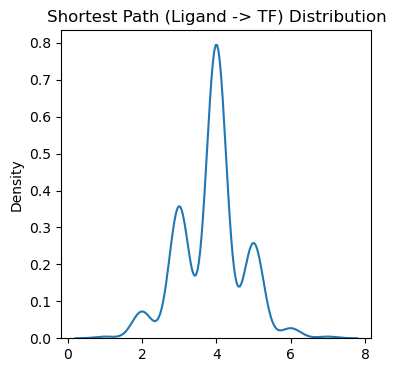

In [12]:
G = nx.from_pandas_edgelist(sn_ppis, 
                            source_label, 
                            target_label,
                            create_using = nx.DiGraph() if sn_ppis[sn_ppis.is_directed].shape[0] == sn_ppis.shape[0] else None)

path_lengths = []
for tf_name in tf_adata.var_names:
    if nx.has_path(G, source="IFNB1", target=tf_name):
        path_lengths.append(nx.shortest_path_length(G, source="IFNB1", target=tf_name))
            
            
fig, ax = plt.subplots(figsize = (4,4))
ax.set_title('Shortest Path (Ligand -> TF) Distribution')
sns.kdeplot(path_lengths, ax = ax)
;

The spectral radius of the recurrent weight matrix controls the stability and effective depth of an RNN’s dynamics. When the spectral radius is small (≪ 1), the RNN is strongly contractive, causing hidden states to collapse rapidly to a fixed point and converge in only a few iterations, but with relatively trivial dynamics. As training progresses, optimization can increase the spectral radius, weakening contraction and allowing information to propagate across more steps; this yields richer, longer-horizon dynamics but requires more iterations to converge. When the spectral radius approaches 1 from below, convergence slows substantially and the RNN effectively “uses” its iterative depth, whereas values above 1 lead to instability and divergent or oscillatory behavior. The observed increase in RNN steps over training, alongside spectral radii remaining below the target, reflects this tradeoff between stability and expressivity within a contractive regime.

We therefore visualize the relationship between spectral radius and the number of RNN iterations to directly assess how learned stability properties translate into effective computational depth. Plotting these quantities together makes explicit how changes in contraction strength govern convergence behavior over training.

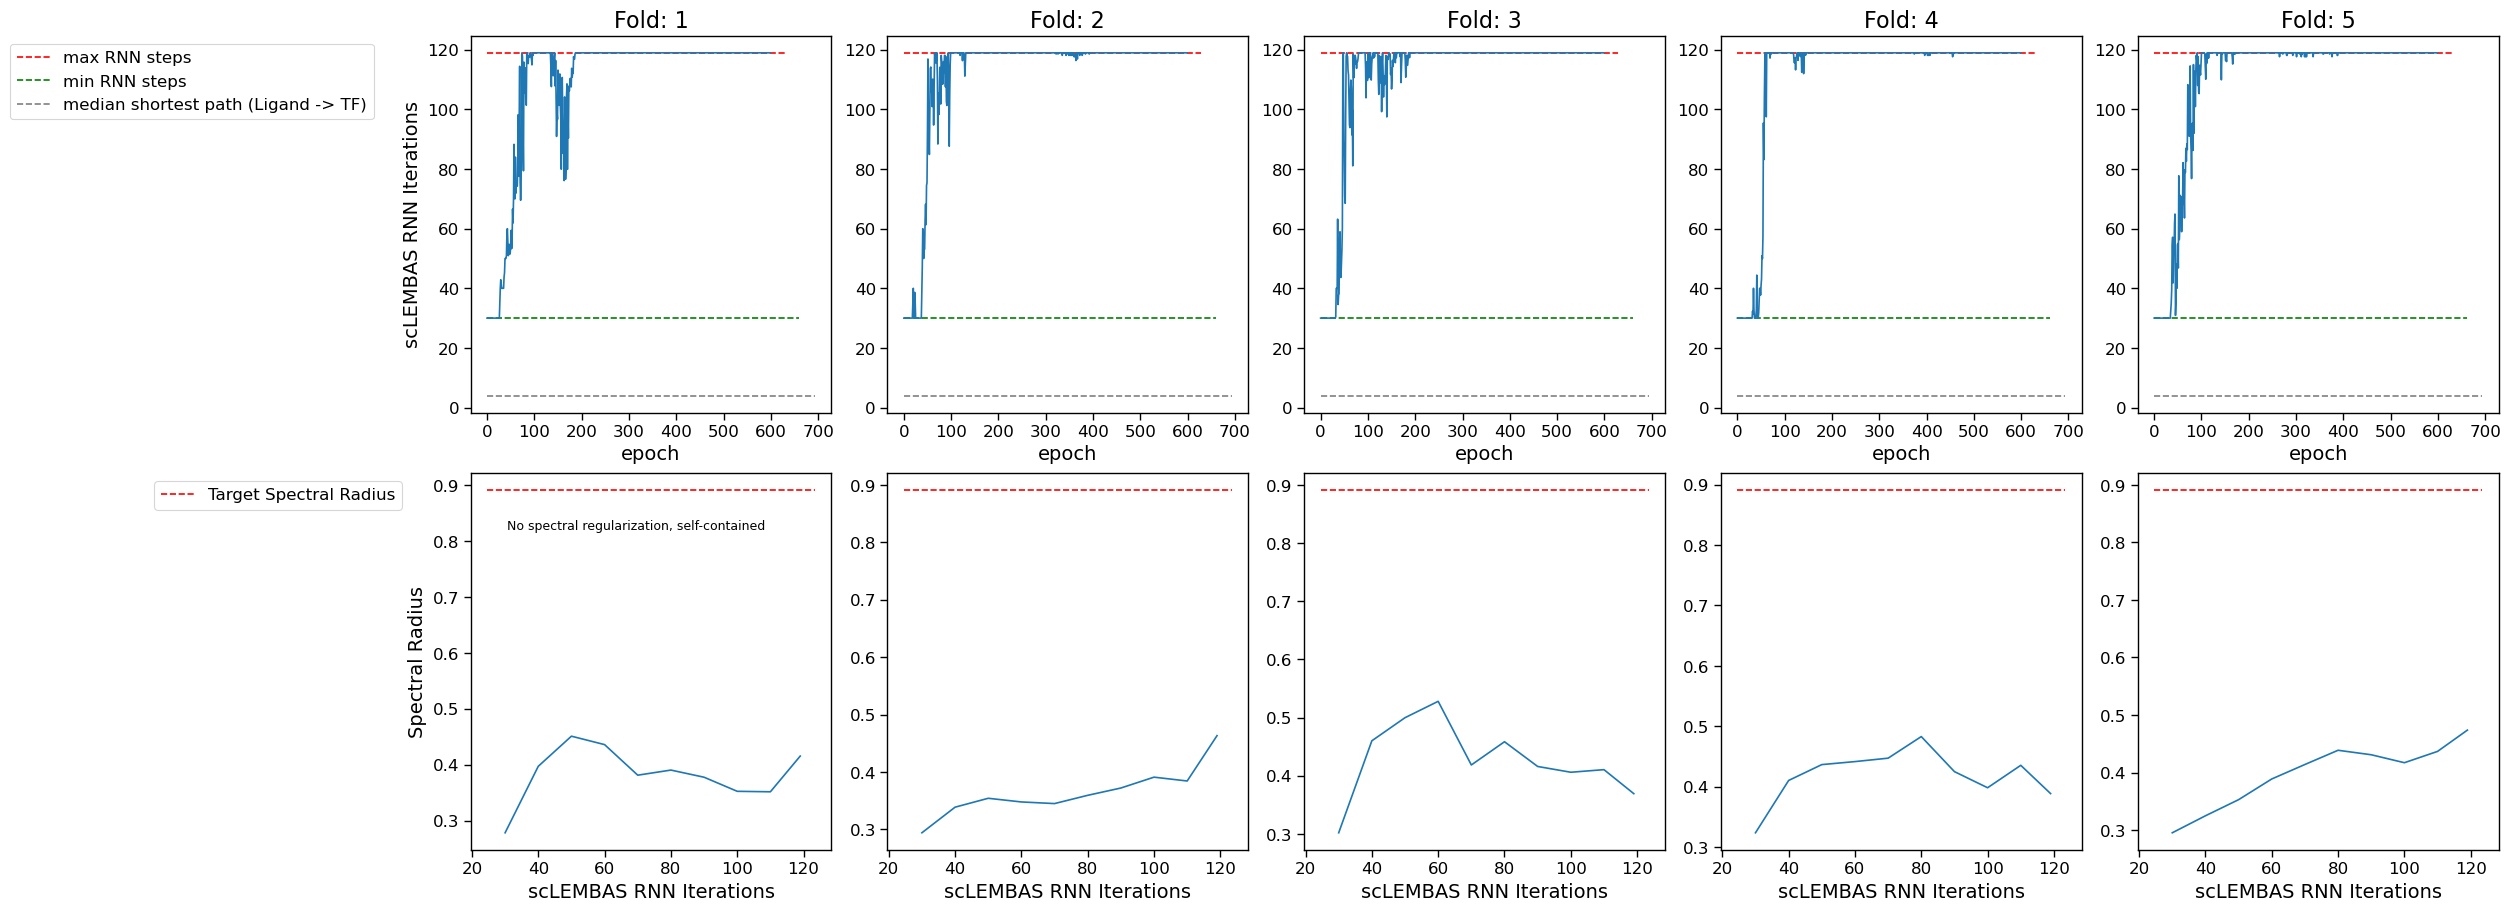

In [7]:
##### PLOTTING #####
with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):


    fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize = (25, 9), constrained_layout = True)


    for j in range(5):

        trainer = viz_dict[j]['trainer']
        viz_df = viz_dict[j]['train_stats'].copy()
        viz_df.epoch -= 1

        i = 0
        sns.lineplot(data = viz_df, x = 'epoch', y = 'rnn_iter_t', zorder = 1, errorbar = None, ax = ax[i,j])
        max_steps = trainer.mod.signaling_network.bionet_params['max_steps'] - 1

        ax[i,j].hlines(
            max_steps,
            xmin = 0,
            xmax = ax[i,j].get_xlim()[1], 
            label = 'max RNN steps',
            color = 'red', linestyle = '--', zorder = 0)

        ax[i,j].hlines(
            30, # hardcoded in bionetwork
            xmin = 0,
            xmax = ax[i,j].get_xlim()[1], 
            label = 'min RNN steps',
            color = 'green', linestyle = '--', zorder = 0)


        ax[i,j].hlines(
            np.median(path_lengths),
            xmin = 0,
            xmax = ax[i,j].get_xlim()[1], 
            label = 'median shortest path (Ligand -> TF)',
            color = 'gray', linestyle = '--', zorder = 0)


        ax[i,j].set_title('Fold: {}'.format(j + 1))

        if j == 0:
            ax[i,j].set_ylabel('scLEMBAS RNN Iterations')
            
            ax[i,j].legend(
                loc='upper left',
                bbox_to_anchor=(-1.3, 1)
            )
        else:
            ax[i,j].set_ylabel('')
            
            leg = ax[i, j].get_legend()
            if leg is not None:
                leg.remove()


        i = 1
        # ax[i,j].set_title('RNN Steps vs Spectral Radius')
        sns.lineplot(data = viz_df, y = 'spectral_radius', x = 'rnn_iter_t', errorbar = None, ax = ax[i,j])
        ax[i,j].hlines(
            trainer.mod.signaling_network.bionet_params['spectral_target'],
            xmin = ax[i,j].get_xlim()[0] - 1,
            xmax = ax[i,j].get_xlim()[1], 
            label = 'Target Spectral Radius',
            color = 'red', linestyle = '--', zorder = 0)
        ax[i,j].set_xlabel('scLEMBAS RNN Iterations')
 
        if j == 0:
            ax[i,j].set_ylabel('Spectral Radius')
            
            ax[i,j].legend(
                loc='upper left',
                bbox_to_anchor=(-0.9, 1)
            )
            slf = trainer.hyper_params['spectral_loss_factor']
            if slf != 0:
                slf_annotate = 'Spectral loss regularization: {:.2E}'.format(slf)
            else:
                slf_annotate = 'No spectral regularization, self-contained'.format(slf)
            ax[i,j].annotate(slf_annotate,
                            xy = (0.1, 0.85), xycoords='axes fraction', fontsize = 9) 
        else:
            ax[i,j].set_ylabel('')

            leg = ax[i, j].get_legend()
            if leg is not None:
                leg.remove()
    ;

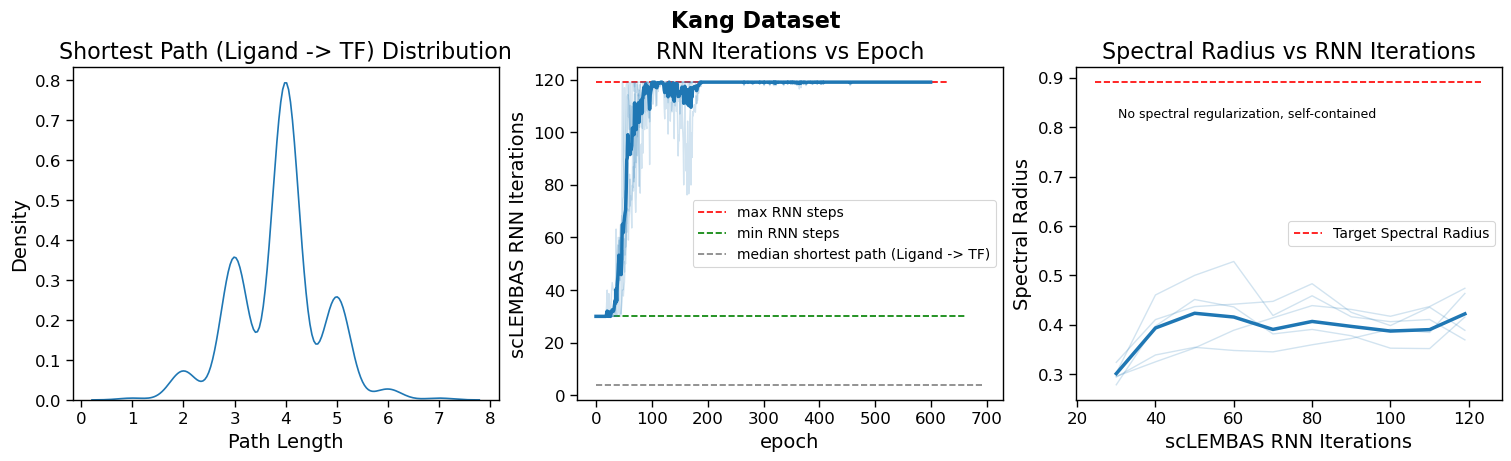

In [16]:
##### PLOTTING #####
with sns.plotting_context(
    "paper", font_scale=1.1,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 10,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5), constrained_layout=True)

    all_viz_dfs = {}
    for j in range(5):
        viz_df = viz_dict[j]['train_stats'].copy()
        viz_df.epoch -= 1
        all_viz_dfs[j] = viz_df

    # --- Column 0: Shortest Path Distribution ---
    G = nx.from_pandas_edgelist(sn_ppis,
                                source_label,
                                target_label,
                                create_using=nx.DiGraph() if sn_ppis[sn_ppis.is_directed].shape[0] == sn_ppis.shape[0] else None)

    path_lengths = []
    for tf_name in tf_adata.var_names:
        if nx.has_path(G, source="IFNB1", target=tf_name):
            path_lengths.append(nx.shortest_path_length(G, source="IFNB1", target=tf_name))

    sns.kdeplot(path_lengths, ax=ax[0])
    ax[0].set_title('Shortest Path (Ligand -> TF) Distribution')
    ax[0].set_xlabel('Path Length')
    ax[0].set_ylabel('Density')

    # --- Column 1: RNN Iterations vs Epoch ---
    i = 1
    for j in range(5):
        viz_df = all_viz_dfs[j]
        first_line = sns.lineplot(data=viz_df, x='epoch', y='rnn_iter_t', zorder=1, errorbar=None,
                     ax=ax[i], alpha=0.2, linewidth=1)
        if j == 0:
            line_color_0 = first_line.get_lines()[0].get_color()
        else:
            first_line.get_lines()[-1].set_color(line_color_0)

    avg_df = pd.concat(all_viz_dfs.values()).groupby('epoch')['rnn_iter_t'].mean().reset_index()
    sns.lineplot(data=avg_df, x='epoch', y='rnn_iter_t', zorder=2, errorbar=None,
                 ax=ax[i], alpha=1, linewidth=2.5, color=line_color_0)

    trainer = viz_dict[0]['trainer']
    max_steps = trainer.mod.signaling_network.bionet_params['max_steps'] - 1
    ax[i].hlines(max_steps, xmin=0, xmax=ax[i].get_xlim()[1],
                 label='max RNN steps', color='red', linestyle='--', zorder=0)
    ax[i].hlines(30, xmin=0, xmax=ax[i].get_xlim()[1],
                 label='min RNN steps', color='green', linestyle='--', zorder=0)
    ax[i].hlines(np.median(path_lengths), xmin=0, xmax=ax[i].get_xlim()[1],
                 label='median shortest path (Ligand -> TF)', color='gray', linestyle='--', zorder=0)
    ax[i].set_title('RNN Iterations vs Epoch')
    ax[i].set_ylabel('scLEMBAS RNN Iterations')
    ax[i].legend(loc='center right')

    # --- Column 2: Spectral Radius vs RNN Iterations ---
    i = 2
    for j in range(5):
        viz_df = all_viz_dfs[j]
        first_line = sns.lineplot(data=viz_df, y='spectral_radius', x='rnn_iter_t', errorbar=None,
                     ax=ax[i], alpha=0.2, linewidth=1)
        if j == 0:
            line_color_1 = first_line.get_lines()[0].get_color()
        else:
            first_line.get_lines()[-1].set_color(line_color_1)

    avg_df2 = pd.concat(all_viz_dfs.values()).groupby('rnn_iter_t')['spectral_radius'].mean().reset_index()
    sns.lineplot(data=avg_df2, y='spectral_radius', x='rnn_iter_t', errorbar=None,
                 ax=ax[i], alpha=1, linewidth=2.5, color=line_color_1)

    ax[i].hlines(trainer.mod.signaling_network.bionet_params['spectral_target'],
                 xmin=ax[i].get_xlim()[0] - 1, xmax=ax[i].get_xlim()[1],
                 label='Target Spectral Radius', color='red', linestyle='--', zorder=0)
    ax[i].set_xlabel('scLEMBAS RNN Iterations')
    ax[i].set_title('Spectral Radius vs RNN Iterations')
    ax[i].set_ylabel('Spectral Radius')
    ax[i].legend(loc='center right')

    slf = trainer.hyper_params['spectral_loss_factor']
    if slf != 0:
        slf_annotate = 'Spectral loss regularization: {:.2E}'.format(slf)
    else:
        slf_annotate = 'No spectral regularization, self-contained'.format(slf)
    ax[i].annotate(slf_annotate, xy=(0.1, 0.85), xycoords='axes fraction', fontsize=9)

    fig.suptitle('{} Dataset'.format(author), fontsize=16, fontweight='bold')
    fig.savefig(os.path.join(data_path, 'figures', '{}_training_dynamics.png'.format(author)), dpi=600, bbox_inches='tight')
    ;

This is the same across folds, won't visualize differences:

# Constant Across Folds

## Learning Rates

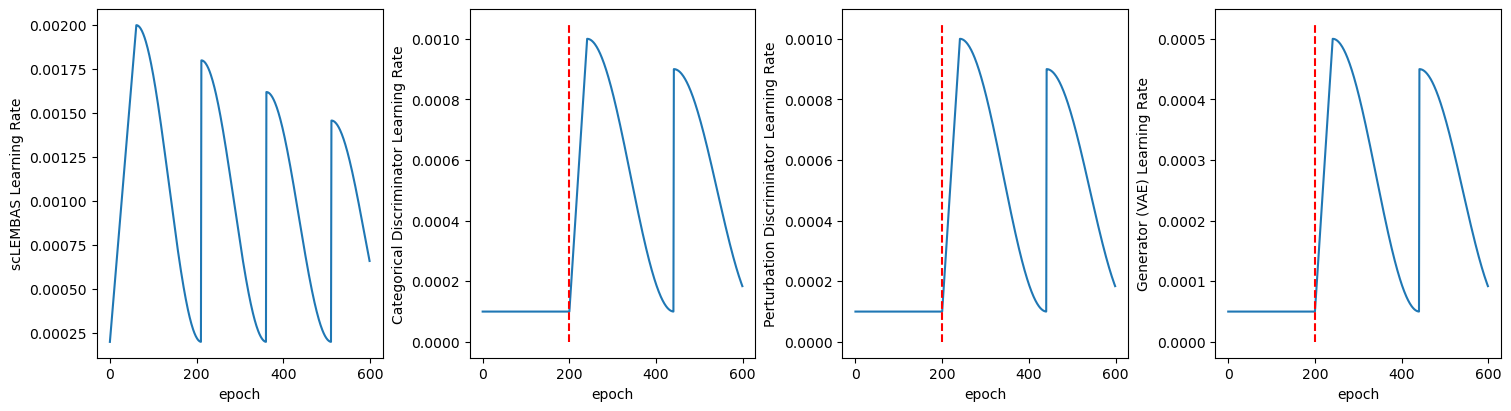

In [8]:
viz_df = train_stats_df.copy()
viz_df.epoch -= 1
fig, ax = plt.subplots(ncols = 4, figsize = (15, 4), constrained_layout = True)

sns.lineplot(data = viz_df, x = 'epoch', y = 'learning_rate', errorbar = None, ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'cat_discriminator_learning_rate', errorbar = None, ax = ax[1])
ax[1].set_ylabel('Categorical Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'pert_discriminator_learning_rate', errorbar = None, ax = ax[2])
ax[2].set_ylabel('Perturbation Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'vae_learning_rate', errorbar = None, ax = ax[3])
ax[3].set_ylabel('Generator (VAE) Learning Rate')

for i in [1, 2, 3]:
    if trainer.n_adversarial_start != 0:
        ax[i].vlines(trainer.n_adversarial_start, 
                     ymin = 0, 
                     ymax = ax[i].get_ylim()[1], color = 'red', linestyle = '--')


# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_epochs' + '.png'), dpi=300, bbox_inches='tight')


## Network Noise

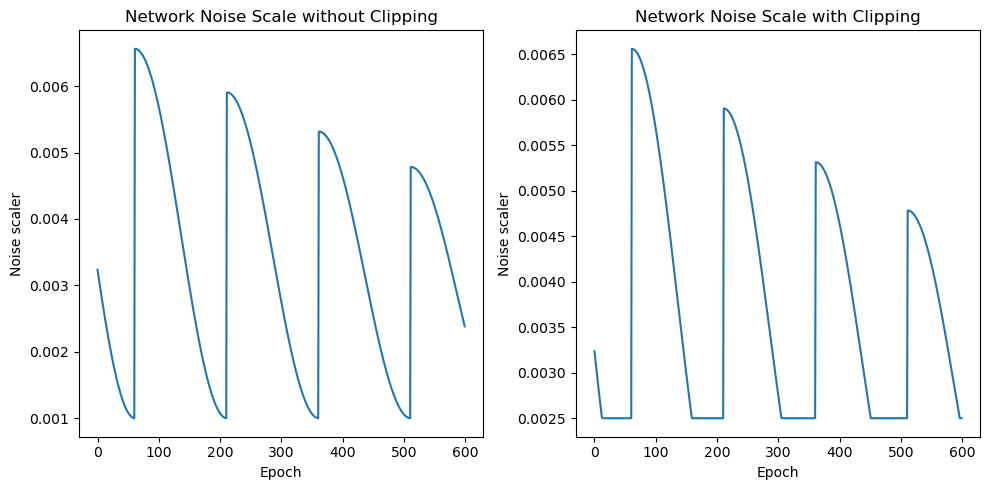

In [9]:
import copy
trainer_2 = copy.deepcopy(trainer)

min_network_noise = trainer_2.hyper_params['min_network_noise']

noise_tracker = []
noise_tracker_unclipped = []
for e in range(trainer_2.hyper_params['max_epochs']):
    cur_lr = trainer_2.prediction_optimizer.param_groups[0]['lr']
    noise_scale = trainer_2.hyper_params['network_noise_scale']*cur_lr/trainer_2.lr_scheduler.max_lr
    noise_tracker_unclipped.append(noise_scale)
    noise_tracker.append(max(noise_scale, min_network_noise))
    trainer_2.lr_scheduler.step()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))

sns.lineplot(noise_tracker_unclipped, errorbar = None, ax = ax[0])
ax[0].set_title('Network Noise Scale without Clipping')

sns.lineplot(noise_tracker, zorder = 0, errorbar = None, ax = ax[1])
# ax[1].hlines(
#     min_network_noise,
#     xmin = 0,  xmax=len(noise_tracker) - 1,
#     color = 'red', linestyle = '--', zorder = 1)
ax[1].set_title('Network Noise Scale with Clipping')

for i in range(2):
    ax[i].set_ylabel('Noise scaler')
    ax[i].set_xlabel('Epoch')
fig.tight_layout()
;
del trainer_2

# MOA Violations

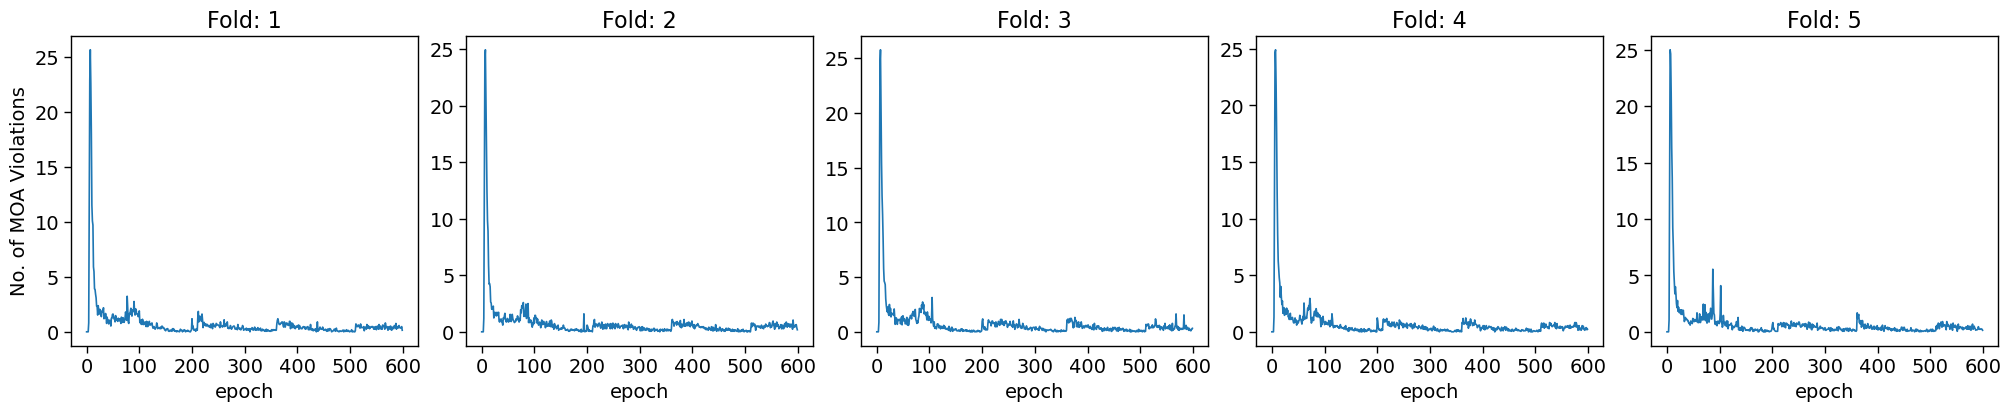

In [10]:
with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
#         "legend.fontsize": 12,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
):

    fig, ax = plt.subplots(ncols = 5, figsize = (20, 4), constrained_layout = True)


    for j in range(5):
        viz_df = viz_dict[j]['train_stats'].copy()
        viz_df.epoch -= 1    

        sns.lineplot(data = viz_df, x = 'epoch', y = 'n_moa_violations', errorbar = None, ax = ax[j])
        if j == 0:
            ax[j].set_ylabel('No. of MOA Violations')
        else:
            ax[j].set_ylabel('')
        ax[j].set_title('Fold: {}'.format(j + 1))
        


# Train Loss Curves

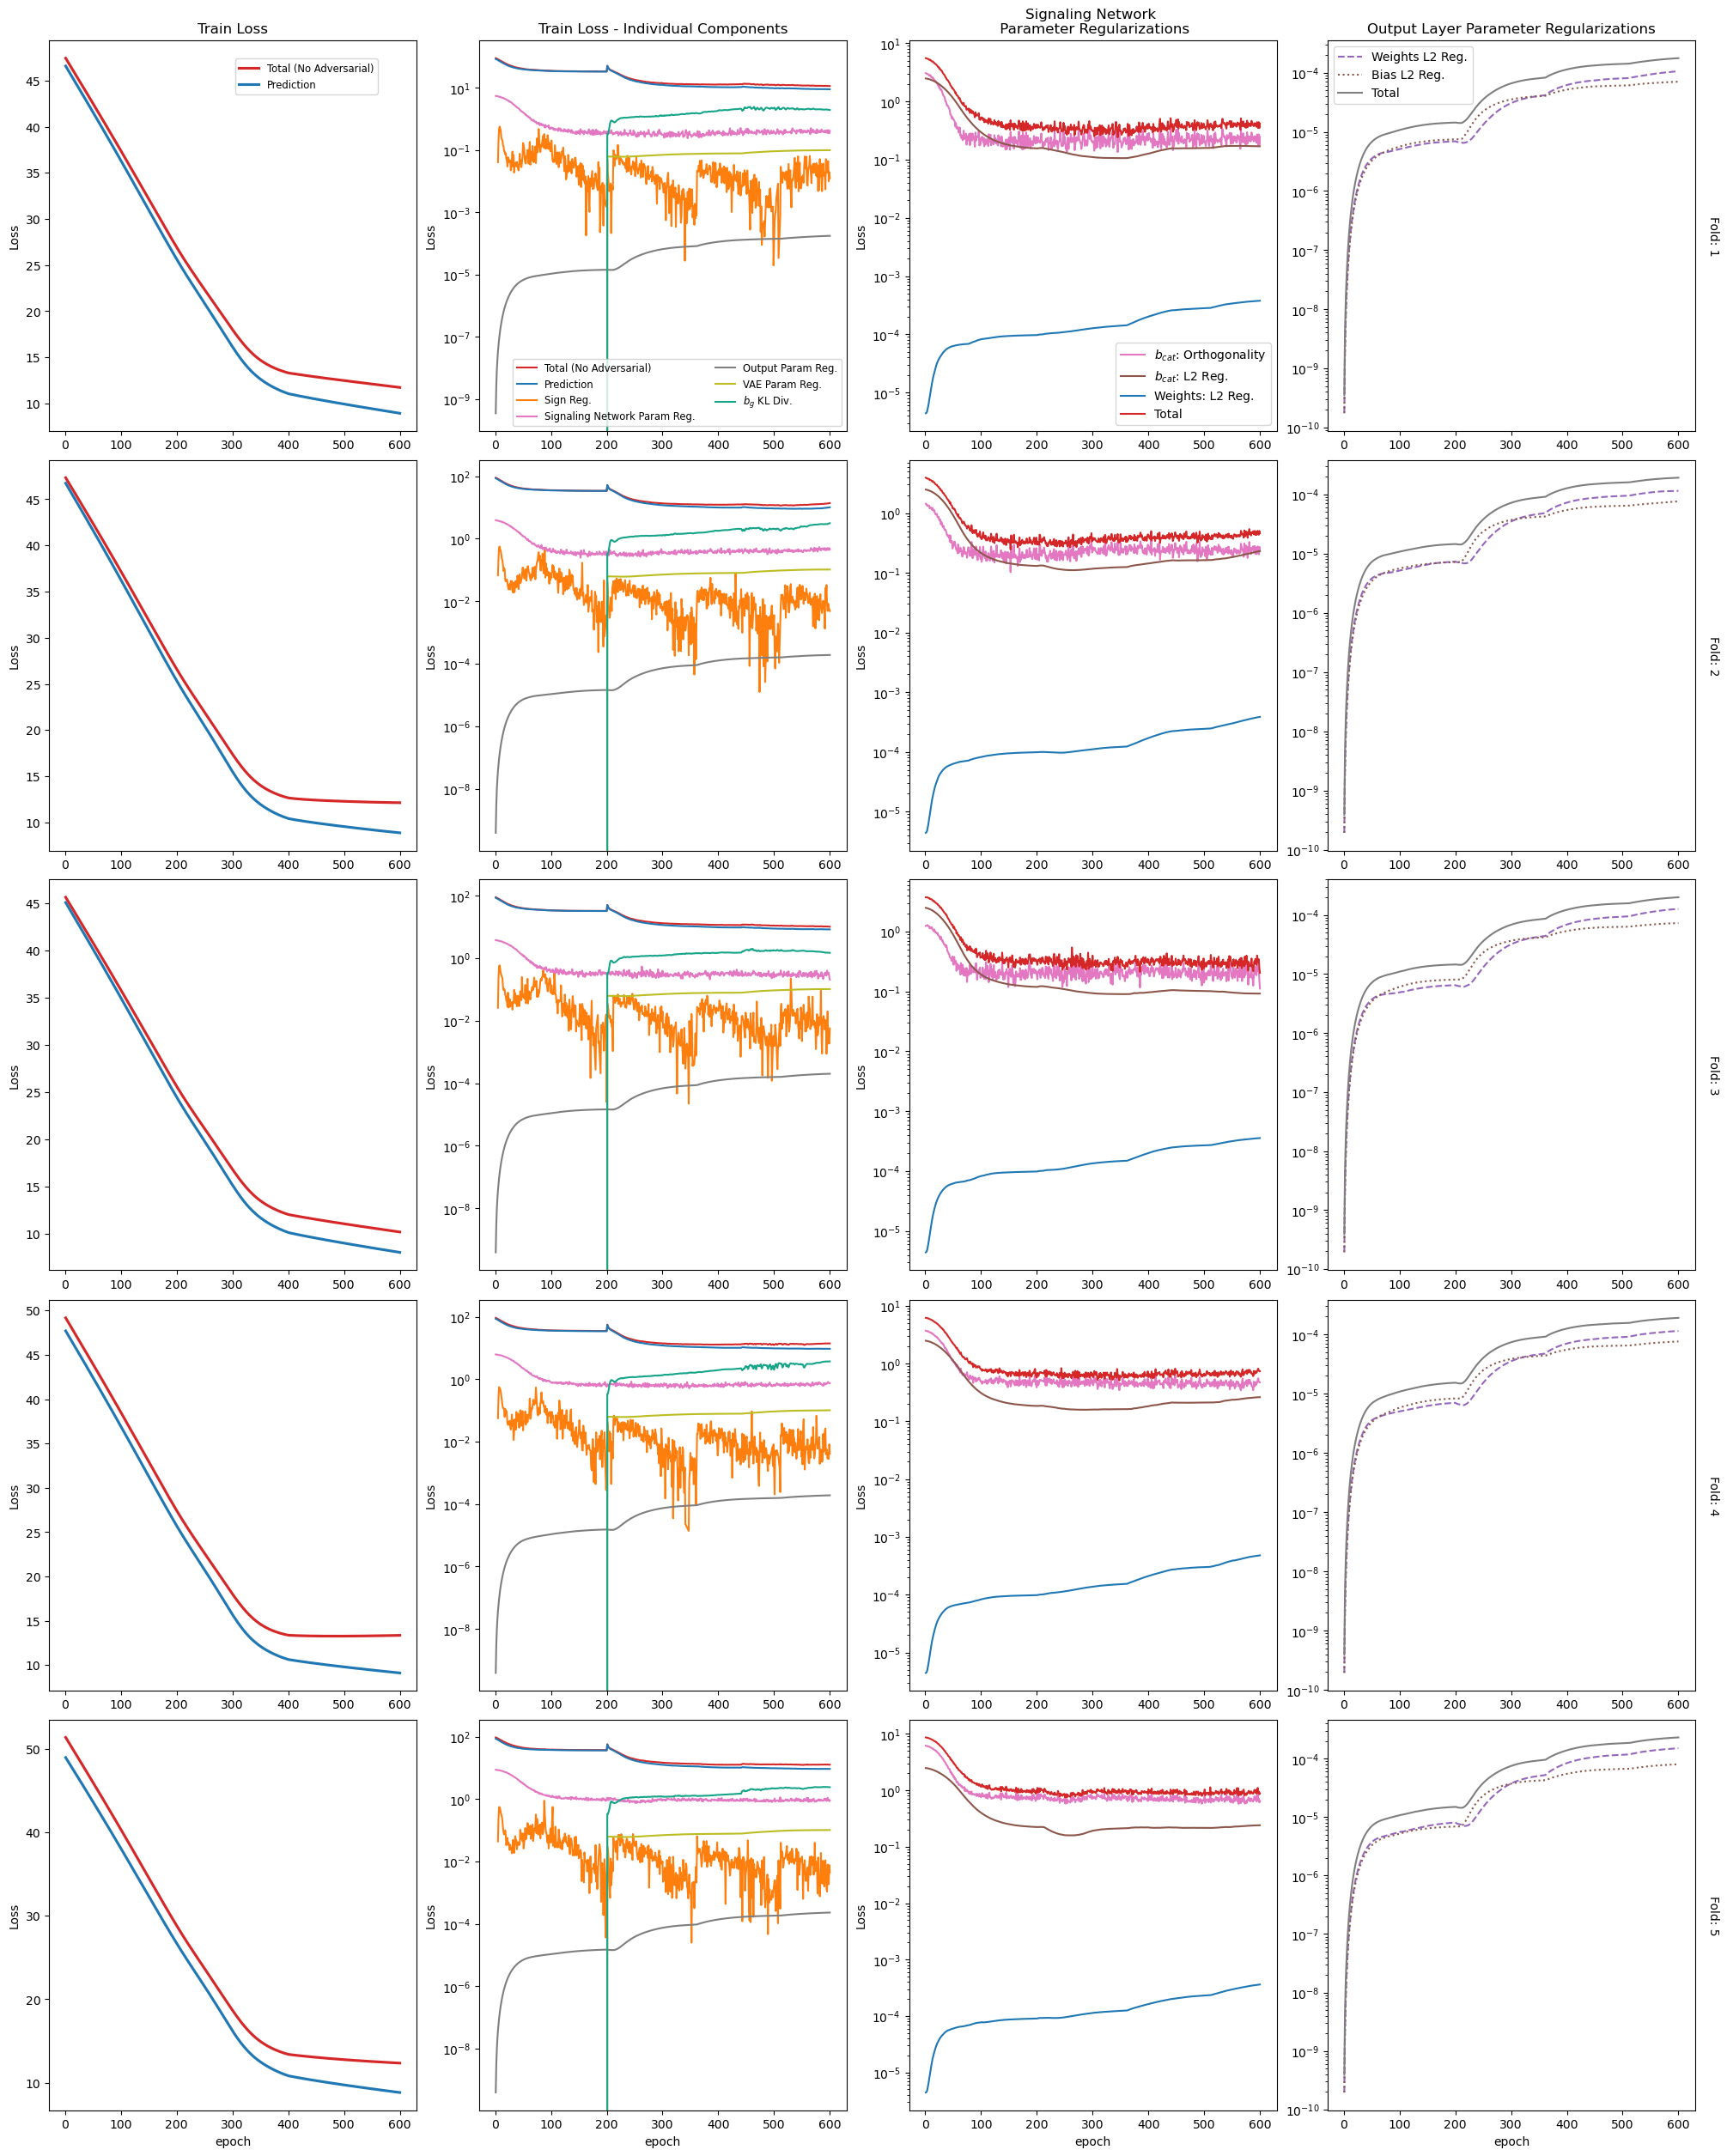

In [17]:
def plot_loss_row_for_fold(train_stats_df_fold, ax_row):
    """
    Your existing code, but operating on the provided fold-specific dataframe
    and the provided 4 axes in this row.
    """
    # ---- keep your existing color setup exactly ----
    colors = [
        "#d62728",  # Red
        "#1f77b4",  # Blue
        "#ff7f0e",  # Orange
        "#2ca02c",  # Green
        "#9467bd",  # Purple
        "#8c564b",  # Brown
        "#e377c2",  # Pink
        "#7f7f7f",  # Gray
        "#bcbd22",  # Olive
        "#17a589",  #  Teal 
        "#FFD700",  # Yellow 
        "#ff9896",  # Light red
    ]
    palette = sns.color_palette(colors)

    # =======================
    # prediction loss
    # =======================
    j = 0
    loss_cols_main = [
        'train_loss_prediction', 'sign_reg_loss',
        'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
        'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss',
        'global_bias_kl_divergence', 'contrastive_loss_total'
    ]

    viz_df = train_stats_df_fold[['epoch'] + loss_cols_main].copy()
    viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis=1)

    viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
    viz_df.loss_type = pd.Categorical(
        viz_df.loss_type,
        ordered=True,
        categories=['total_train_loss_no_adverserial'] + loss_cols_main
    )

    loss_map = {
        'train_loss_prediction': 'Prediction',
        'sign_reg_loss': 'Sign Reg.',
        'stability_reg_loss': 'Spectral Reg.',
        'uniform_reg_loss': 'Uniform Reg.',
        'contrastive_loss_total': 'Contrastive Reg.',
        'input_param_reg_loss': 'Input Param Reg.',
        'sn_param_reg_tot_loss': 'Signaling Network Param Reg.',
        'output_param_reg_tot_loss': 'Output Param Reg.',
        'vae_param_reg_loss': 'VAE Param Reg.',
        'global_bias_kl_divergence': r'$b_g$' + ' KL Div.',
        'total_train_loss_no_adverserial': 'Total (No Adversarial)'
    }
    viz_df.loss_type = viz_df.loss_type.map(loss_map)

    # drop all 0s, retain coloring order, do not show in legend
    colors_map = dict(zip(viz_df.loss_type.cat.categories, colors))
    zeros = (
        viz_df.groupby("loss_type", observed=False)["loss"]
              .agg(lambda s: (s.size > 0) and np.all(s.values == 0))
    )
    zeros = zeros[zeros].index.values.tolist()
    viz_df = viz_df[~viz_df.loss_type.isin(zeros)].copy()
    viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories().copy()

    loss_cols_sub = ['Total (No Adversarial)', 'Prediction']

    for lti, loss_type in enumerate(loss_cols_sub):
        sns.regplot(
            data=viz_df[viz_df.loss_type == loss_type],
            x='epoch', y='loss',
            lowess=True, scatter=False,
            color=colors_map[loss_type],
            ax=ax_row[j], label=loss_type
        )
    ax_row[j].legend(loc='lower center', bbox_to_anchor=(0.7, 0.85), ncol=1, fontsize='small')
    ax_row[j].set_title('Train Loss')

    # =======================
    # all losses
    # =======================
    j = 1
    palette_fixed = {lt: colors_map[lt] for lt in viz_df.loss_type.cat.categories}
    sns.lineplot(
        data=viz_df, x='epoch', y='loss', hue='loss_type',
        palette=palette_fixed, errorbar = None,
        ax=ax_row[j]
    )
    ax_row[j].legend(ncol=2, fontsize='small')
    ax_row[j].set_title('Train Loss - Individual Components')
    ax_row[j].set_yscale('log')

    # =======================
    # signaling network weights and bias components
    # =======================
    j = 2
    loss_cols = [
        'sn_param_reg_tot_loss',
        'sn_param_reg_weights_L2_loss',
        'sn_param_reg_weights_kl_divergence',
        'sn_param_reg_global_bias_L2_loss',
        'sn_param_reg_global_bias_L1_loss',
        'sn_param_reg_cat_bias_L2_loss',
        'sn_param_reg_cat_bias_L1_loss',
        'sn_param_reg_cat_bias_pert'
    ][::-1]
    palette = [
        'tab:red', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
        (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
    ][::-1]

    viz_df = train_stats_df_fold[['epoch'] + loss_cols].copy()
    viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

    loss_cols_name = [
        'Total',
        'Weights: L2 Reg.',
        'Weights: KL Divergence',
        r'$b_g$:' ' L2 Reg.',
        r'$b_g$:' ' L1 Reg.',
        r'$b_{cat}$:' ' L2 Reg.',
        r'$b_{cat}$:' ' L1 Reg.',
        r'$b_{cat}$:' ' Orthogonality'
    ][::-1]
    loss_map = dict(zip(loss_cols, loss_cols_name))
    viz_df.loss_type = viz_df.loss_type.map(loss_map)

    zeros = viz_df.groupby('loss_type', observed=False).loss.apply(lambda x: (x == 0).all())
    zeros = np.array(zeros.index)[np.where(zeros)]
    viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
    viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
    palette = [col for i, col in enumerate(palette) if loss_cols_name[i] in viz_df.loss_type.cat.categories]
    palette = dict(zip(viz_df.loss_type.cat.categories, palette))

    for lt in viz_df.loss_type.cat.categories:
        viz_df_ = viz_df[viz_df.loss_type == lt]
        sns.lineplot(
            data=viz_df_, x='epoch', y='loss',
            color=palette[lt],errorbar = None,
            ax=ax_row[j]
        )
    ax_row[j].set_title('Signaling Network \n Parameter Regularizations')
    ax_row[j].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]
    ax_row[j].legend(handles=legend_handles, loc='best')

    # =======================
    # output layer regularizations
    # =======================
    j = 3
    loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
    palette = ['tab:purple', 'tab:brown', (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
    linestyles = ['--', 'dotted', 'solid']

    viz_df = train_stats_df_fold[['epoch'] + loss_cols].copy()
    viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

    loss_cols_name = ['Weights L2 Reg.', 'Bias L2 Reg.', 'Total']
    palette = dict(zip(loss_cols_name, palette))
    linestyles = dict(zip(loss_cols_name, linestyles))
    viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols, loss_cols_name)))

    for lt in loss_cols_name:
        viz_df_ = viz_df[viz_df.loss_type == lt]
        sns.lineplot(
            data=viz_df_, x='epoch', y='loss',
            color=palette[lt], linestyle=linestyles[lt],errorbar = None,
            ax=ax_row[j]
        )
    ax_row[j].set_title('Output Layer Parameter Regularizations')
    ax_row[j].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=palette[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols_name]
    ax_row[j].legend(handles=legend_handles, loc='best')

    for j in range(4):
        ax_row[j].set_ylabel('Loss')

        
folds = range(5)
fig, ax = plt.subplots(nrows=len(folds), ncols=4, figsize=(20, 5*len(folds)), constrained_layout=True)

for r, fold in enumerate(folds):
    train_stats_df_fold = viz_dict[fold]['train_stats'].copy()
    plot_loss_row_for_fold(train_stats_df_fold, ax[r, :])
    
    ax[r, -1].yaxis.set_label_position("right")
    ax[r, -1].set_ylabel('Fold: {}'.format(fold + 1), rotation=270, labelpad=20)
    
    if r > 0:
        for a in ax[r, :]:
            a.set_title("")
            if a.get_legend() is not None:
                a.get_legend().remove()
            
    if r < len(folds) - 1:
        for a in ax[r, :]:
            a.set_xlabel("")
    

plt.show()


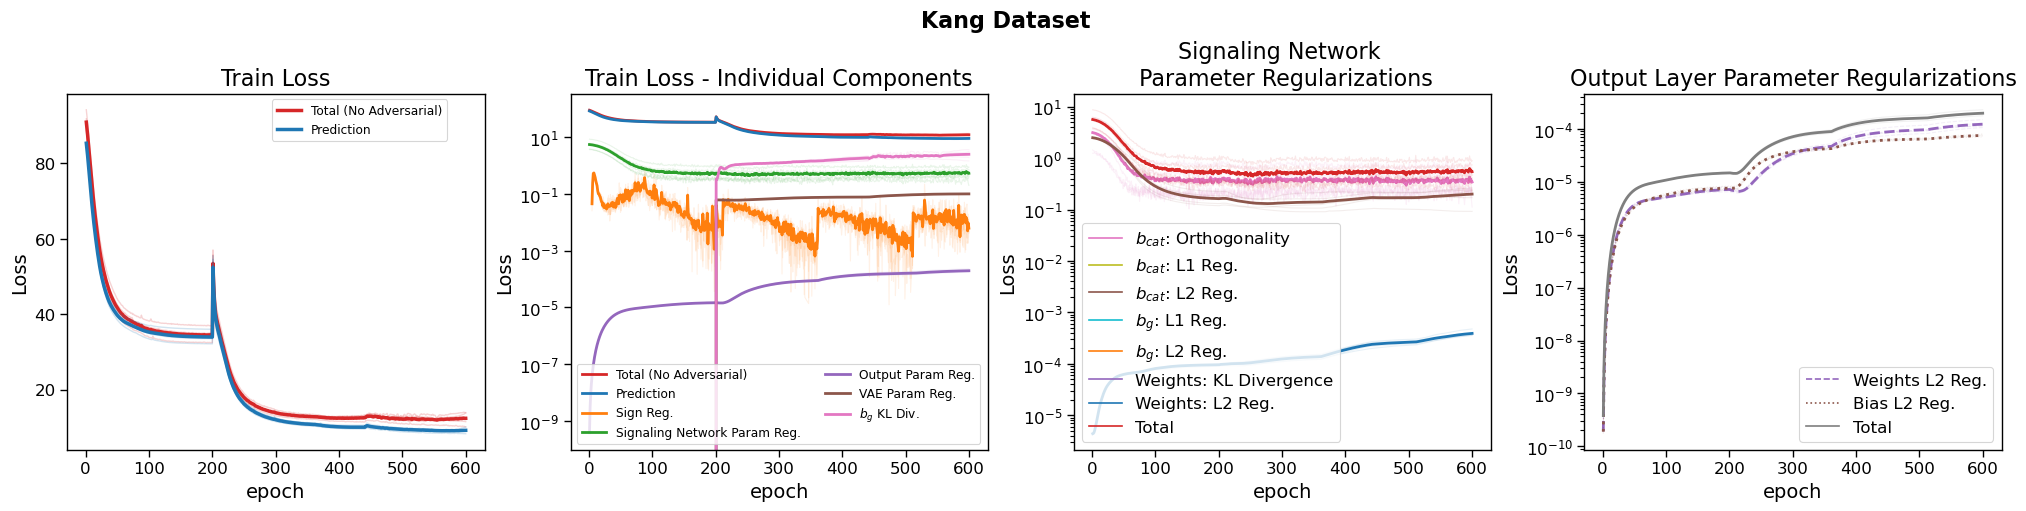

In [19]:
with sns.plotting_context(
    "paper", font_scale=1.1,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):
    colors = [
        "#d62728", "#1f77b4", "#ff7f0e", "#2ca02c",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17a589", "#FFD700", "#ff9896",
    ]

    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), constrained_layout=True)

    all_viz_dfs = {}
    for j in range(5):
        viz_df = viz_dict[j]['train_stats'].copy()
        all_viz_dfs[j] = viz_df

    # =======================
    # 1. prediction loss
    # =======================
    j = 0
    loss_cols_main = [
        'train_loss_prediction', 'sign_reg_loss',
        'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
        'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss',
        'global_bias_kl_divergence', 'contrastive_loss_total'
    ]

    loss_map = {
        'train_loss_prediction': 'Prediction',
        'sign_reg_loss': 'Sign Reg.',
        'stability_reg_loss': 'Spectral Reg.',
        'uniform_reg_loss': 'Uniform Reg.',
        'contrastive_loss_total': 'Contrastive Reg.',
        'input_param_reg_loss': 'Input Param Reg.',
        'sn_param_reg_tot_loss': 'Signaling Network Param Reg.',
        'output_param_reg_tot_loss': 'Output Param Reg.',
        'vae_param_reg_loss': 'VAE Param Reg.',
        'global_bias_kl_divergence': r'$b_g$' + ' KL Div.',
        'total_train_loss_no_adverserial': 'Total (No Adversarial)'
    }

    df_all = []
    for k in all_viz_dfs:
        df = all_viz_dfs[k][['epoch'] + loss_cols_main].copy()
        df['total_train_loss_no_adverserial'] = df[loss_cols_main].sum(axis=1)
        df['fold'] = k
        df_all.append(df)
    df_all = pd.concat(df_all)

    viz_df = df_all.melt(id_vars=['epoch', 'fold'], var_name='loss_type', value_name='loss')
    viz_df.loss_type = pd.Categorical(
        viz_df.loss_type,
        ordered=True,
        categories=['total_train_loss_no_adverserial'] + loss_cols_main
    )
    viz_df.loss_type = viz_df.loss_type.map(loss_map)

    zeros = (
        viz_df.groupby("loss_type", observed=False)["loss"]
        .agg(lambda s: (s.size > 0) and np.all(s.values == 0))
    )
    zeros = zeros[zeros].index.values.tolist()
    viz_df = viz_df[~viz_df.loss_type.isin(zeros)].copy()
    viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories().copy()

    colors_map = dict(zip(viz_df.loss_type.cat.categories, colors))
    loss_cols_sub = ['Total (No Adversarial)', 'Prediction']

    for lt in loss_cols_sub:
        color = colors_map[lt]

        for k in all_viz_dfs:
            sub = viz_df[(viz_df.fold == k) & (viz_df.loss_type == lt)]
            first_line = sns.lineplot(
                data=sub, x='epoch', y='loss',
                ax=ax[j], alpha=0.2, linewidth=1,
                color=color, errorbar=None
            )
            first_line.get_lines()[-1].set_color(color)

        mean_df = (
            viz_df[viz_df.loss_type == lt]
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=mean_df, x='epoch', y='loss',
            ax=ax[j], alpha=1, linewidth=2.5,
            color=color, label=lt, errorbar=None
        )

    ax[j].legend(loc='lower center', bbox_to_anchor=(0.7, 0.85), ncol=1, fontsize='small')
    ax[j].set_title('Train Loss')

    # =======================
    # 2. all losses
    # =======================
    j = 1
    palette_fixed = {lt: colors_map[lt] for lt in viz_df.loss_type.cat.categories}

    for lt in viz_df.loss_type.cat.categories:
        color = palette_fixed[lt]

        for k in all_viz_dfs:
            sub = viz_df[(viz_df.fold == k) & (viz_df.loss_type == lt)]
            first_line = sns.lineplot(
                data=sub, x='epoch', y='loss',
                ax=ax[j], alpha=0.1, linewidth=0.8,
                color=color, errorbar=None
            )
            first_line.get_lines()[-1].set_color(color)

        mean_df = (
            viz_df[viz_df.loss_type == lt]
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=mean_df, x='epoch', y='loss',
            ax=ax[j], alpha=1, linewidth=2,
            color=color, label=lt, errorbar=None
        )

    ax[j].legend(ncol=2, fontsize='small')
    ax[j].set_title('Train Loss - Individual Components')
    ax[j].set_yscale('log')

    # =======================
    # 3. signaling network weights and bias components
    # =======================
    j = 2
    loss_cols = [
        'sn_param_reg_tot_loss',
        'sn_param_reg_weights_L2_loss',
        'sn_param_reg_weights_kl_divergence',
        'sn_param_reg_global_bias_L2_loss',
        'sn_param_reg_global_bias_L1_loss',
        'sn_param_reg_cat_bias_L2_loss',
        'sn_param_reg_cat_bias_L1_loss',
        'sn_param_reg_cat_bias_pert'
    ][::-1]
    palette_sn = [
        'tab:red', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
        (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
    ][::-1]

    loss_cols_name = [
        'Total',
        'Weights: L2 Reg.',
        'Weights: KL Divergence',
        r'$b_g$:' ' L2 Reg.',
        r'$b_g$:' ' L1 Reg.',
        r'$b_{cat}$:' ' L2 Reg.',
        r'$b_{cat}$:' ' L1 Reg.',
        r'$b_{cat}$:' ' Orthogonality'
    ][::-1]
    loss_map_sn = dict(zip(loss_cols, loss_cols_name))

    df_sn = []
    for k in all_viz_dfs:
        df = all_viz_dfs[k][['epoch'] + loss_cols].copy()
        df['fold'] = k
        df_sn.append(df)
    df_sn = pd.concat(df_sn)

    viz_df_sn = df_sn.melt(id_vars=['epoch', 'fold'], var_name='loss_type', value_name='loss')
    viz_df_sn.loss_type = pd.Categorical(viz_df_sn.loss_type, ordered=True, categories=loss_cols)
    viz_df_sn.loss_type = viz_df_sn.loss_type.map(loss_map_sn)

    zeros = viz_df_sn.groupby('loss_type', observed=False).loss.apply(lambda x: (x == 0).all())
    zeros = np.array(zeros.index)[np.where(zeros)]
    viz_df_sn = viz_df_sn[~viz_df_sn.loss_type.isin(zeros)]
    viz_df_sn.loss_type = viz_df_sn.loss_type.astype('category')

    palette_sn = [col for i, col in enumerate(palette_sn) if loss_cols_name[i] in viz_df_sn.loss_type.cat.categories]
    palette_sn = dict(zip(viz_df_sn.loss_type.cat.categories, palette_sn))

    for lt in viz_df_sn.loss_type.cat.categories:
        color = palette_sn[lt]

        for k in all_viz_dfs:
            sub = viz_df_sn[(viz_df_sn.fold == k) & (viz_df_sn.loss_type == lt)]
            first_line = sns.lineplot(
                data=sub, x='epoch', y='loss',
                color=color, errorbar=None,
                ax=ax[j], alpha=0.1, linewidth=0.8
            )
            first_line.get_lines()[-1].set_color(color)

        mean_df = (
            viz_df_sn[viz_df_sn.loss_type == lt]
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=mean_df, x='epoch', y='loss',
            color=color, errorbar=None,
            ax=ax[j], alpha=1, linewidth=2, label=lt
        )

    ax[j].set_title('Signaling Network \n Parameter Regularizations')
    ax[j].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=palette_sn[lt], label=lt) for lt in viz_df_sn.loss_type.cat.categories]
    ax[j].legend(handles=legend_handles, loc='best')

    # =======================
    # 4. output layer regularizations
    # =======================
    j = 3
    loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
    palette_out = ['tab:purple', 'tab:brown', (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
    linestyles = ['--', 'dotted', 'solid']

    loss_cols_name = ['Weights L2 Reg.', 'Bias L2 Reg.', 'Total']
    palette_out = dict(zip(loss_cols_name, palette_out))
    linestyles = dict(zip(loss_cols_name, linestyles))

    df_out = []
    for k in all_viz_dfs:
        df = all_viz_dfs[k][['epoch'] + loss_cols].copy()
        df['fold'] = k
        df_out.append(df)
    df_out = pd.concat(df_out)

    viz_df_out = df_out.melt(id_vars=['epoch', 'fold'], var_name='loss_type', value_name='loss')
    viz_df_out.loss_type = pd.Categorical(viz_df_out.loss_type, ordered=True, categories=loss_cols)
    viz_df_out.loss_type = viz_df_out.loss_type.map(dict(zip(loss_cols, loss_cols_name)))

    for lt in loss_cols_name:
        color = palette_out[lt]
        linestyle = linestyles[lt]

        for k in all_viz_dfs:
            sub = viz_df_out[(viz_df_out.fold == k) & (viz_df_out.loss_type == lt)]
            first_line = sns.lineplot(
                data=sub, x='epoch', y='loss',
                color=color, linestyle=linestyle, errorbar=None,
                ax=ax[j], alpha=0.1, linewidth=0.8
            )
            first_line.get_lines()[-1].set_color(color)

        mean_df = (
            viz_df_out[viz_df_out.loss_type == lt]
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=mean_df, x='epoch', y='loss',
            color=color, linestyle=linestyle, errorbar=None,
            ax=ax[j], alpha=1, linewidth=2, label=lt
        )

    ax[j].set_title('Output Layer Parameter Regularizations')
    ax[j].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=palette_out[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols_name]
    ax[j].legend(handles=legend_handles, loc='best')

    for j in range(4):
        ax[j].set_ylabel('Loss')

    fig.suptitle('{} Dataset'.format(author), fontsize=16, fontweight='bold')
    fig.savefig(os.path.join(data_path, 'figures', '{}_regularization_dynamics.png'.format(author)),
                dpi=600, bbox_inches='tight')
    ;

# Evaluation Loss Curves

In [20]:
# palette = sns.color_palette([
#     "#e377c2",  # Pink
#     "#6baed6",  # light blue
# ])


# fig, ax = plt.subplots(ncols = 5, figsize = (20, 4), constrained_layout=True)


# for j in range(5):
    
#     eval_df = viz_dict[j]['eval_df'].copy()
    
#     sns.lineplot(data = eval_df, x = 'epoch', y = 'loss_full', hue = 'loss_type', 
#                  palette = palette,errorbar = None,
#                  ax = ax[j])
#     ax[j].set_title('Fold: {}'.format(j + 1))
    
#     if j == 0:
#         ax[j].set_ylabel('Prediction {} Loss'.format(trainer._prediction_loss_name))
#         ax[j].legend(title = None, 
#                      loc='upper left',bbox_to_anchor=(-0.9, 1))
#     else:
#         ax[j].set_ylabel('')
#         leg = ax[j].get_legend()
#         if leg is not None:
#             leg.remove()
        
        
# ;

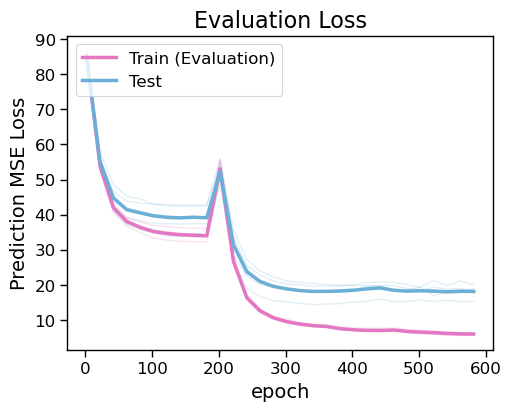

In [21]:
with sns.plotting_context(
    "paper", font_scale=1.1,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):
    palette = sns.color_palette([
        "#e377c2",  # Pink
        "#6baed6",  # light blue
    ])

    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

    all_eval_dfs = {}
    for j in range(5):
        eval_df = viz_dict[j]['eval_df'].copy()
        all_eval_dfs[j] = eval_df

    loss_type_order = list(pd.unique(pd.concat(all_eval_dfs.values())['loss_type']))
    color_map = dict(zip(loss_type_order, palette[:len(loss_type_order)]))

    for j in range(5):
        eval_df = all_eval_dfs[j]
        for lt in loss_type_order:
            sub = eval_df[eval_df['loss_type'] == lt]
            first_line = sns.lineplot(
                data=sub, x='epoch', y='loss_full',
                ax=ax, alpha=0.2, linewidth=1,
                color=color_map[lt], errorbar=None
            )
            if j == 0:
                color_map[lt] = first_line.get_lines()[-1].get_color()
            else:
                first_line.get_lines()[-1].set_color(color_map[lt])

    combined = pd.concat(all_eval_dfs.values())
    for lt in loss_type_order:
        sub = combined[combined['loss_type'] == lt]
        avg_df = sub.groupby('epoch')['loss_full'].mean().reset_index()
        sns.lineplot(
            data=avg_df, x='epoch', y='loss_full',
            ax=ax, alpha=1, linewidth=2.5,
            color=color_map[lt], label=lt, errorbar=None
        )

    ax.set_title('Evaluation Loss')
    ax.set_ylabel('Prediction {} Loss'.format(trainer._prediction_loss_name))
    ax.legend(title=None, loc='upper left')

    fig.savefig(os.path.join(data_path, 'figures', '{}_evaluation_dynamics.png'.format(author)),
                dpi=600, bbox_inches='tight')
    ;

# Adversarial Curves

<span style="color:red">Move to adversarial notebooks</span>

In [5]:
sys.path.insert(1, '../../.') 
from notebook_utils import get_split

# Penalty Schedule

''

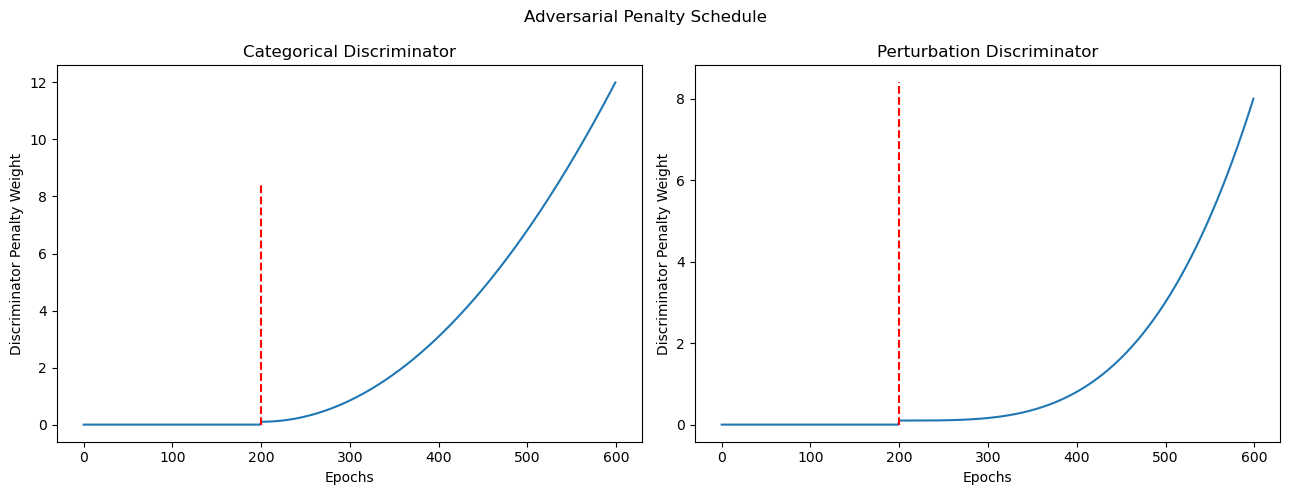

In [14]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(trainer.cat_discriminator['params']['discriminator_penalty_weight'], errorbar = None,ax = ax[0])
ax[0].set_title('Categorical Discriminator')


sns.lineplot(trainer.pert_discriminator['params']['discriminator_penalty_weight'], errorbar = None,ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
    if trainer.n_adversarial_start != 0:
        ax[i].vlines(trainer.n_adversarial_start, ymin = 0, ymax = ax[1].get_ylim()[1], color = 'red', linestyle = '--')

fig.suptitle('Adversarial Penalty Schedule')    
fig.tight_layout()
;


# Gradients
- Discriminator: Bad if L2 norm is > 100 (see number [10](https://github.com/soumith/ganhacks))
- Generator: if gradient disappears quick (standard GANs), not able to learn anything

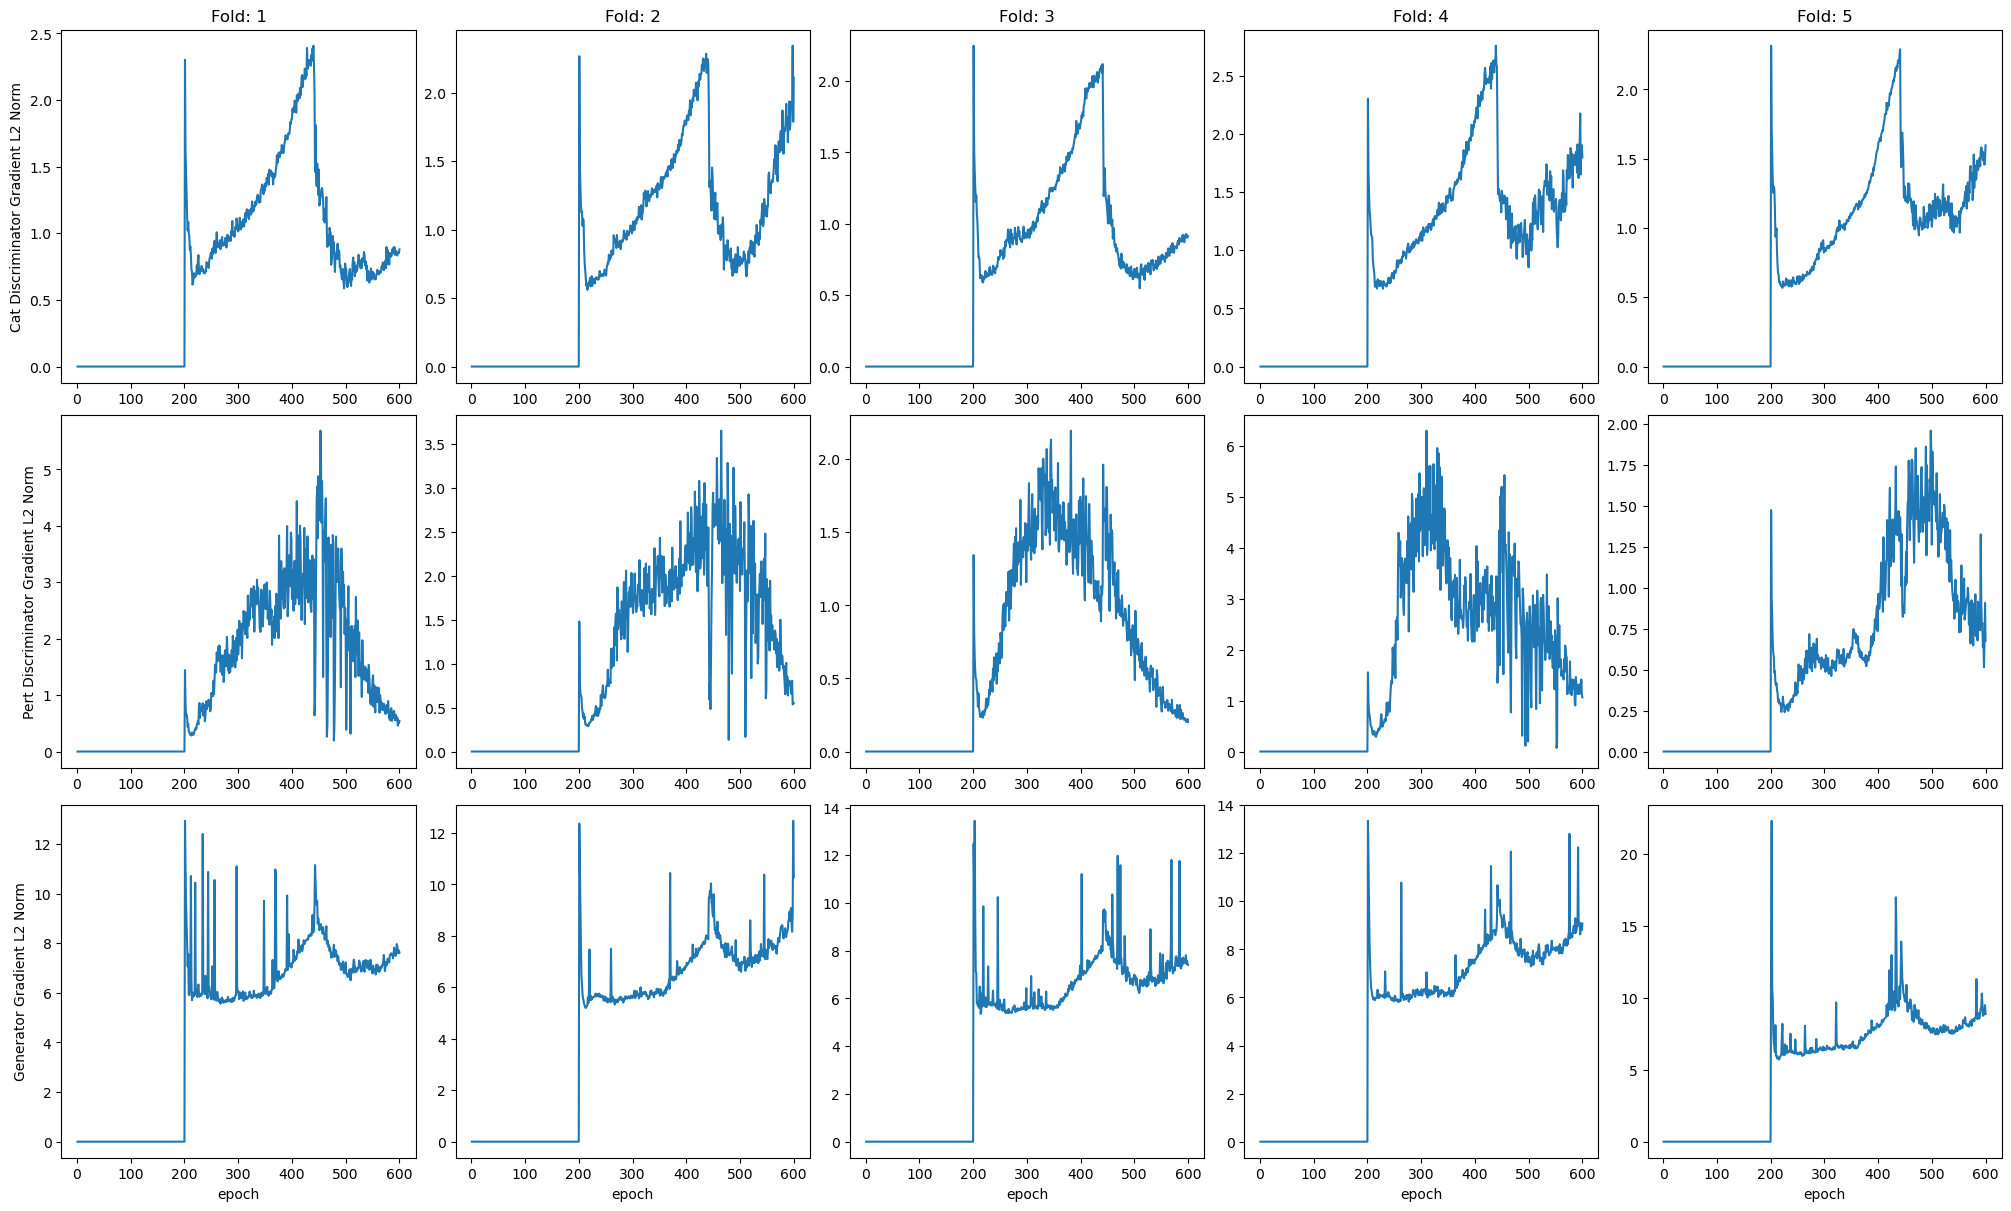

In [15]:
fig, ax = plt.subplots(nrows = 3, ncols = 5, figsize = (20, 12), constrained_layout = True)



for j in range(5):
    train_stats_df = viz_dict[j]['train_stats']
    
    i = 0
    sns.lineplot(data = train_stats_df, x = 'epoch', errorbar = None,
                 y = 'cat_' + cat_col + '_discriminator_grad_l2_norm', ax = ax[i,j])
    ax[i,j].set_ylabel('Cat Discriminator Gradient L2 Norm')
    ax[i,j].set_title('Fold: {}'.format(j + 1))

    i = 1
    sns.lineplot(data = train_stats_df, x = 'epoch', errorbar = None,
                 y = 'pert_discriminator_grad_l2_norm', ax = ax[i,j])
    ax[i,j].set_ylabel('Pert Discriminator Gradient L2 Norm')

    i = 2
    sns.lineplot(data = train_stats_df, x = 'epoch', errorbar = None,
                 y = 'vae_grad_l2_norm', ax = ax[i,j])
    ax[i,j].set_ylabel('Generator Gradient L2 Norm')

for i in range(3):   
    for j in range(1,5):
        ax[i,j].set_ylabel('')
        
for i in range(2):
    for j in range(5):
        ax[i,j].set_xlabel('')
        


# Train Loss

<span style="color:red">Add no adversarial curves for comparison</span>

In [16]:
# if author != 'McCauley':
#     raise ValueError('This function is not necessary, can use the discriminator native function')
# def corrected_random_loss(discriminator, class_probs, train_mode = True):
#     """
#     `To replace CatDiscriminator.random_loss of post-trained models with incorrect KL div calculation for random loss`
#     """
#     if len(class_probs) != discriminator.n_labels:
#         raise ValueError('The class_probs must be the same length as discriminator.n_labels')

#     eps = discriminator.epsilon_smooth if (train_mode and discriminator.smooth_labels) else 0
#     if discriminator.n_labels == 2:
#         # Binary classification baseline
#         p1 = class_probs[1]
#         p0 = class_probs[0]

#         # Model outputs random prediction equal to p1
#         y_pred = p1

#         # Target labels after smoothing
#         t1 = 1.0 - eps
#         t0 = eps

#         # BCE(t, y_pred) = -[t * log(y_pred) + (1 - t) * log(1 - y_pred)]
#         bce_1 = - (t1 * np.log(y_pred + 1e-10) + (1 - t1) * np.log(1 - y_pred + 1e-10))
#         bce_0 = - (t0 * np.log(y_pred + 1e-10) + (1 - t0) * np.log(1 - y_pred + 1e-10))

#         return p1 * bce_1 + p0 * bce_0


#     else:
#         if discriminator.smooth_labels: # KL divergence (used in training, kept for eval but with eps = 0)
#             total_kl = 0

#             Q = torch.tensor(class_probs, dtype=torch.float32) # random prediction
#             log_Q = torch.log(Q + 1e-10)

#             for i in range(discriminator.n_labels):
#                 # Smoothed target for class i
#                 one_hot = np.zeros(discriminator.n_labels)
#                 one_hot[i] = 1
#                 smoothed = one_hot * (1 - eps) + eps / discriminator.n_labels

#                 P = torch.tensor(smoothed, dtype=torch.float32) # label-smoothing adjusted true target

#                 # kl = F.kl_div(log_Q, P, reduction='batchmean')
#                 kl = torch.sum(P * (torch.log(P + 1e-10) - log_Q))
#                 total_kl += class_probs[i] * kl.item() # gives a weighted average
#             return total_kl
#         else: # cross entropy
#             return -np.sum(class_probs * np.log(class_probs)) 


In [6]:
colors = [
    "#d62728",  # Red
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#ff9896",   # Light red
    "#1f77b4",  # Blue
    "#8c564b",  # Brown
    "#17a589",  #  Teal 
    "#bcbd22",  # Olive
    "#9467bd",  # Purple
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#6baed6",  # light blue

]
palette = sns.color_palette(colors)


def plot_adversarial_loss_row(
    ax_row,
    fold,
):
    split = get_split(fold, author)
    train_cells =  split['train_barcodes']
    trainer = viz_dict[fold]['trainer']
    assert sorted(train_cells) == sorted(trainer.X_train.index), 'Train cell mismatch'

    train_stats_df = viz_dict[fold]['train_stats'].copy()
    
    
    i = 0
    # Plot 1: full model, adverserial loss
    loss_cols_main = ['sign_reg_loss',
           'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
           'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
        'global_bias_kl_divergence']


    loss_cols = ['train_loss_total'] + loss_cols_main + ['cat_adverserial_loss', 'pert_adverserial_loss', 'train_loss_prediction']

    viz_df = train_stats_df[['epoch'] + loss_cols].copy()
    viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main + ['train_loss_prediction']].sum(axis = 1)

    viz_df.drop(columns = loss_cols_main, inplace = True)
    viz_df.drop(columns = ['train_loss_prediction'], inplace = True)

    # for visualization, switch
    if trainer.gradient_ascent:
        for adv_col in ['cat_adverserial_loss', 'pert_adverserial_loss']:
            viz_df[adv_col] = viz_df[adv_col].abs()
        viz_df['train_loss_total'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss - viz_df.pert_adverserial_loss

    viz_df['train_loss: total - cat_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss
    viz_df['train_loss: total - pert_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.pert_adverserial_loss

    # # without this, the total loss without adversarial does not look accurate
    # viz_df = viz_df[keep_gen_mask]


    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')


    loss_cols_sub = ['total_train_loss_no_adverserial',
                     'train_loss: total - cat_adverserial', 
                     'train_loss: total - pert_adverserial',
                     'train_loss_total', 
    #                  'train_loss_prediction',
                     'cat_adverserial_loss',
                     'pert_adverserial_loss']
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_sub)

    loss_cols_name = [
        'Total (No Adversarial)', 
        'Total (With Cat. Adv.)', 
        'Total (With Pert Adv.)',
        'Total (With Cat + Pert Adv.)', 
    #     'Prediction', 
        'Adversarial Loss: Categorical', 
        'Adversarial Loss: Pert'
    ]

    viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_sub, loss_cols_name)))

    for lti, loss_type in enumerate(loss_cols_name):
        sns.regplot(data = viz_df[viz_df.loss_type == loss_type], 
                    x = 'epoch', y = 'loss', 
                    lowess = True, scatter = False, 
                    color = palette[lti], ax = ax_row[i], label = loss_type)

    ax_row[i].legend(loc='upper left', bbox_to_anchor=(-1.3, 1), borderaxespad=0.)
    ax_row[i].set_ylabel('Train Loss')
    ax_row[i].set_title('Full Model')

    i = 1
    # Plot 2: full model, categorical discriminator loss
    loss_cols_disc = ['cat_discriminator_loss_total',
           'cat_discriminator_loss_prediction', 'cat_discriminator_param_reg_loss']

    viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
    viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

    # only show L2 reg (and prediction) if L2 reg is ever non-zero
    if (viz_df[loss_cols_disc[-1]] == 0).all():
        loss_cols_disc = [loss_cols_disc[0]]
        viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
        viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

    loss_cols_name = ['Total', 'Prediction', 'L2 Reg']
    viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_disc, loss_cols_name)))

    sns.lineplot(
        data = viz_df,
        x = 'epoch',
        y = 'loss',
        hue='loss_type',errorbar = None,
        palette = (
            [palette[1]] if loss_cols_disc == [loss_cols_disc[0]]
            else [palette[1], palette[0], palette[-2]]
        ),
        ax = ax_row[i]
    )

    if viz_df['loss_type'].nunique() == 1:
        ax_row[i].legend_.remove()

    cp = tf_adata[train_cells,:].obs[cat_col].value_counts(normalize = True).values
    if author == 'McCauley':
        rand_loss = corrected_random_loss(
            discriminator = trainer.cat_discriminator['discriminators'][cat_col],
            class_probs = cp, train_mode = True)
    else:
        rand_loss=trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp, train_mode = True)

        
    ax_row[i].axhline(y=rand_loss, color='dimgray', linestyle='--')

    if viz_df['loss_type'].nunique() != 1:
        ax_row[i].legend(loc='best')

    ax_row[i].set_ylabel('Train Loss')
    ax_row[i].set_title('Categorical Discriminator')

    i = 2
    # Plot 3: full model, perturbation discriminator loss
    loss_cols_disc = ['pert_discriminator_loss_total',
           'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']

    viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
    viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

    # only show L2 reg (and prediction) if L2 reg is ever non-zero
    if (viz_df[loss_cols_disc[-1]] == 0).all():
        loss_cols_disc = [loss_cols_disc[0]]
        viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
        viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

    loss_cols_name = ['Total', 'Prediction', 'L2 Reg']
    viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_disc, loss_cols_name)))


    sns.lineplot(
        data = viz_df,
        x = 'epoch',
        y = 'loss',
        hue='loss_type',errorbar = None,
        palette = (
            [palette[2]] if loss_cols_disc == [loss_cols_disc[0]]
            else [palette[2], palette[0], palette[-2]]
        ),
        ax = ax_row[i]
    )

    if viz_df['loss_type'].nunique() == 1:
        ax_row[i].legend_.remove()

    cp = tf_adata[train_cells,:].obs[pert_col].value_counts(normalize = True).values


    if author == 'McCauley':
        rand_loss = corrected_random_loss(
            discriminator = trainer.pert_discriminator['discriminator'],
            class_probs = cp, train_mode = True)
    else:
        rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp, train_mode = True)


    ax_row[i].axhline(y=rand_loss, color='dimgray', linestyle='--')


    if viz_df['loss_type'].nunique() != 1:
        ax_row[i].legend(loc='best')

    ax_row[i].set_ylabel('Train Loss')
    ax_row[i].set_title('Perturbation Discriminator')


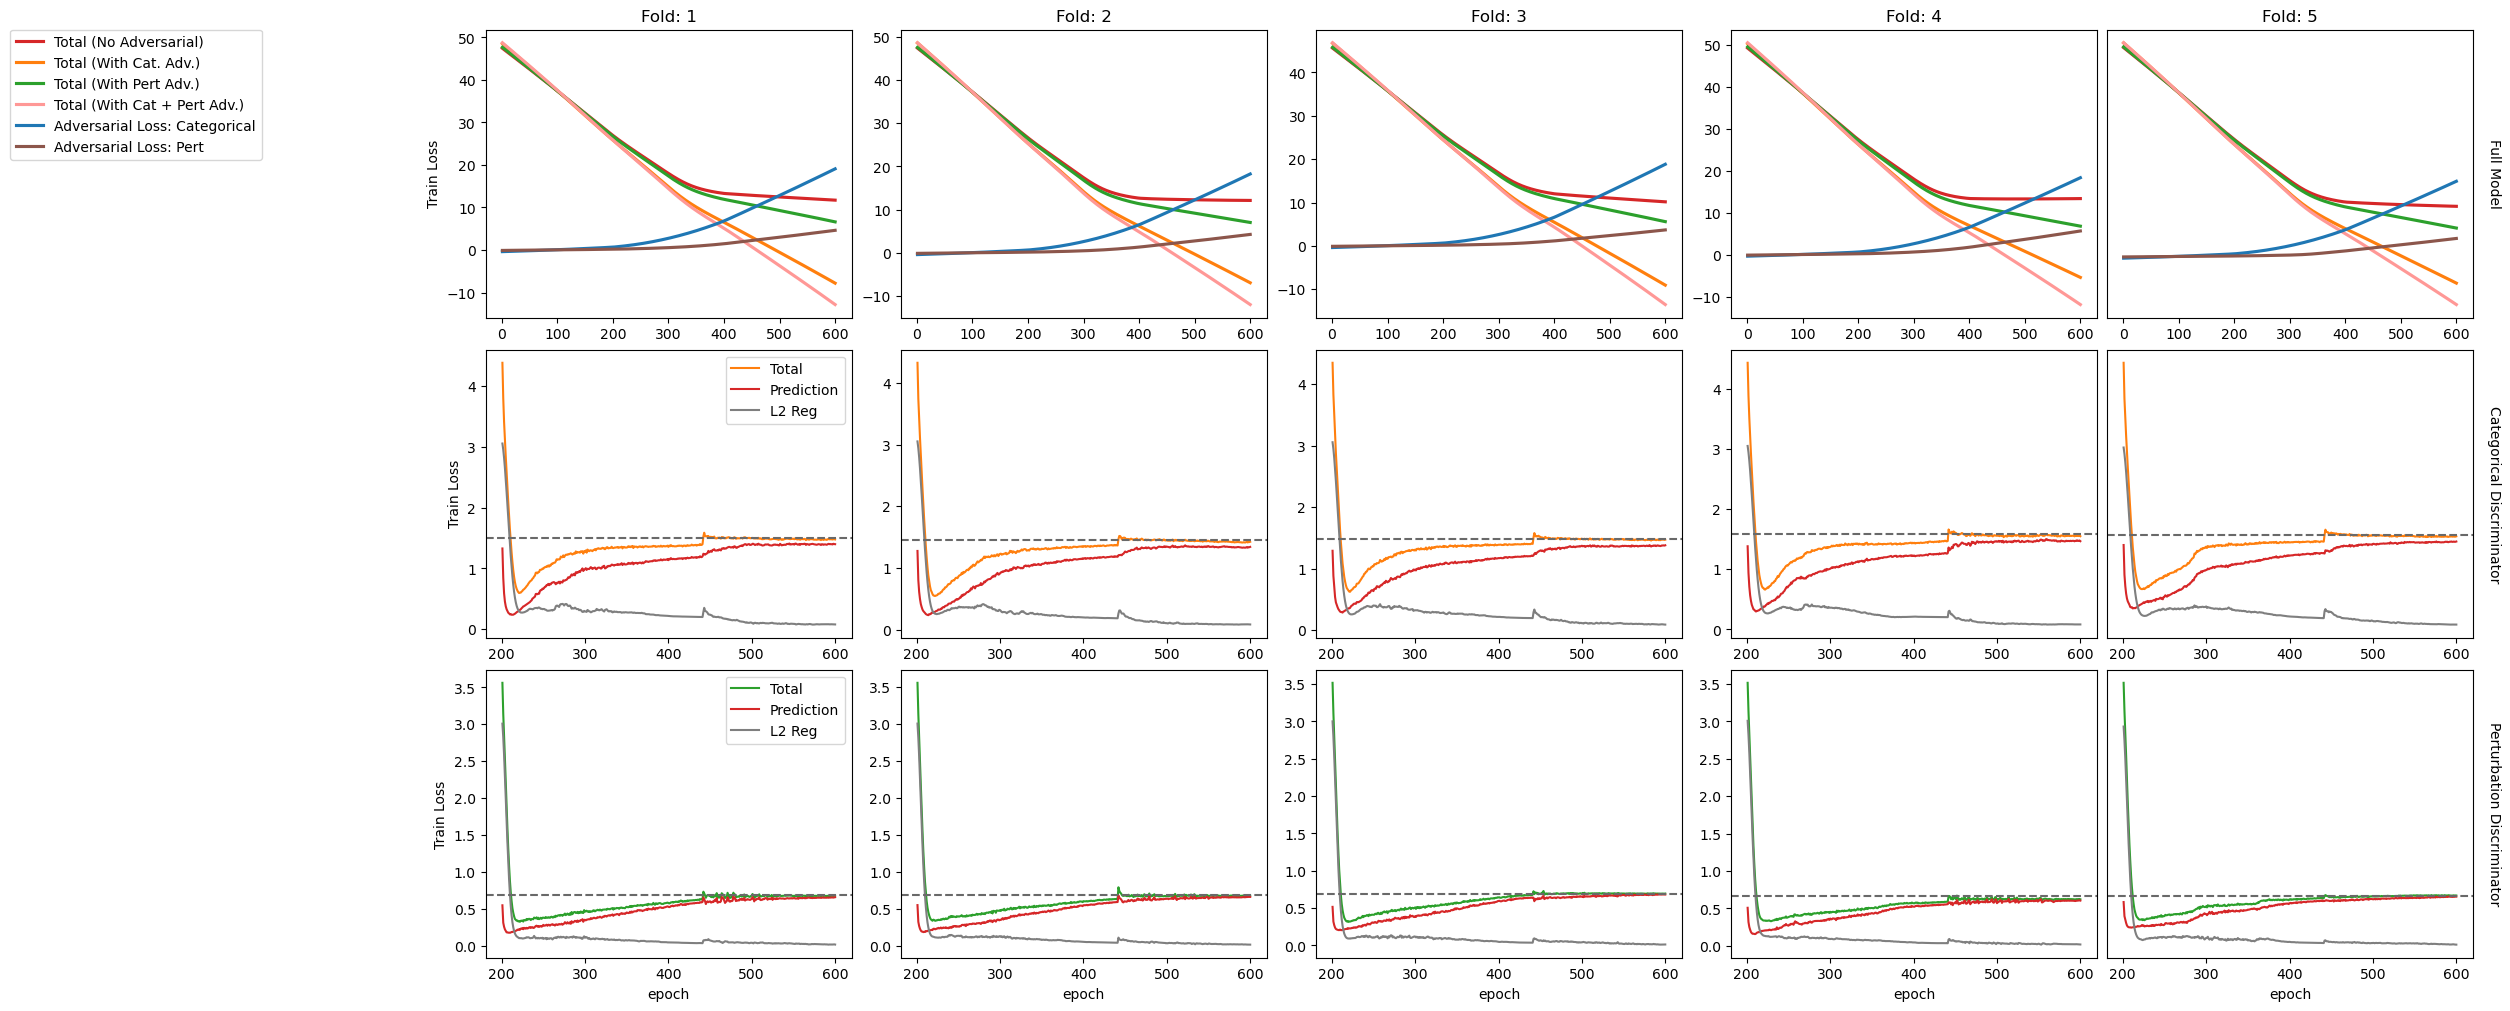

In [18]:
fig, ax = plt.subplots(nrows=3, ncols=5, figsize=(25, 10), constrained_layout=True)
n_rows, n_folds = ax.shape

old_titles = ['Full Model', 'Categorical Discriminator', 'Perturbation Discriminator']

for fold in range(n_folds):
    plot_adversarial_loss_row(
        ax_row=ax[:, fold],
        fold = fold
    )
    
    if fold != 0:
        for a in ax[:, fold]:
            if a.get_legend() is not None:
                a.get_legend().remove()
                
    for r in range(n_rows):
        a = ax[r, fold]        
        
        a.set_title('')
        
        if r != n_rows - 1:
            a.set_xlabel('')
        else:
            a.set_xlabel('epoch')

        if fold != 0:
            a.set_ylabel('')
    
    ax[0, fold].set_title('Fold: {}'.format(fold + 1))
    
    
for r in range(n_rows):
    a = ax[r, -1]
    a.set_ylabel(old_titles[r], rotation=270, labelpad=20)
    a.yaxis.set_label_position("right")
    a.yaxis.tick_right()
    a.tick_params(right=False, labelright=False)

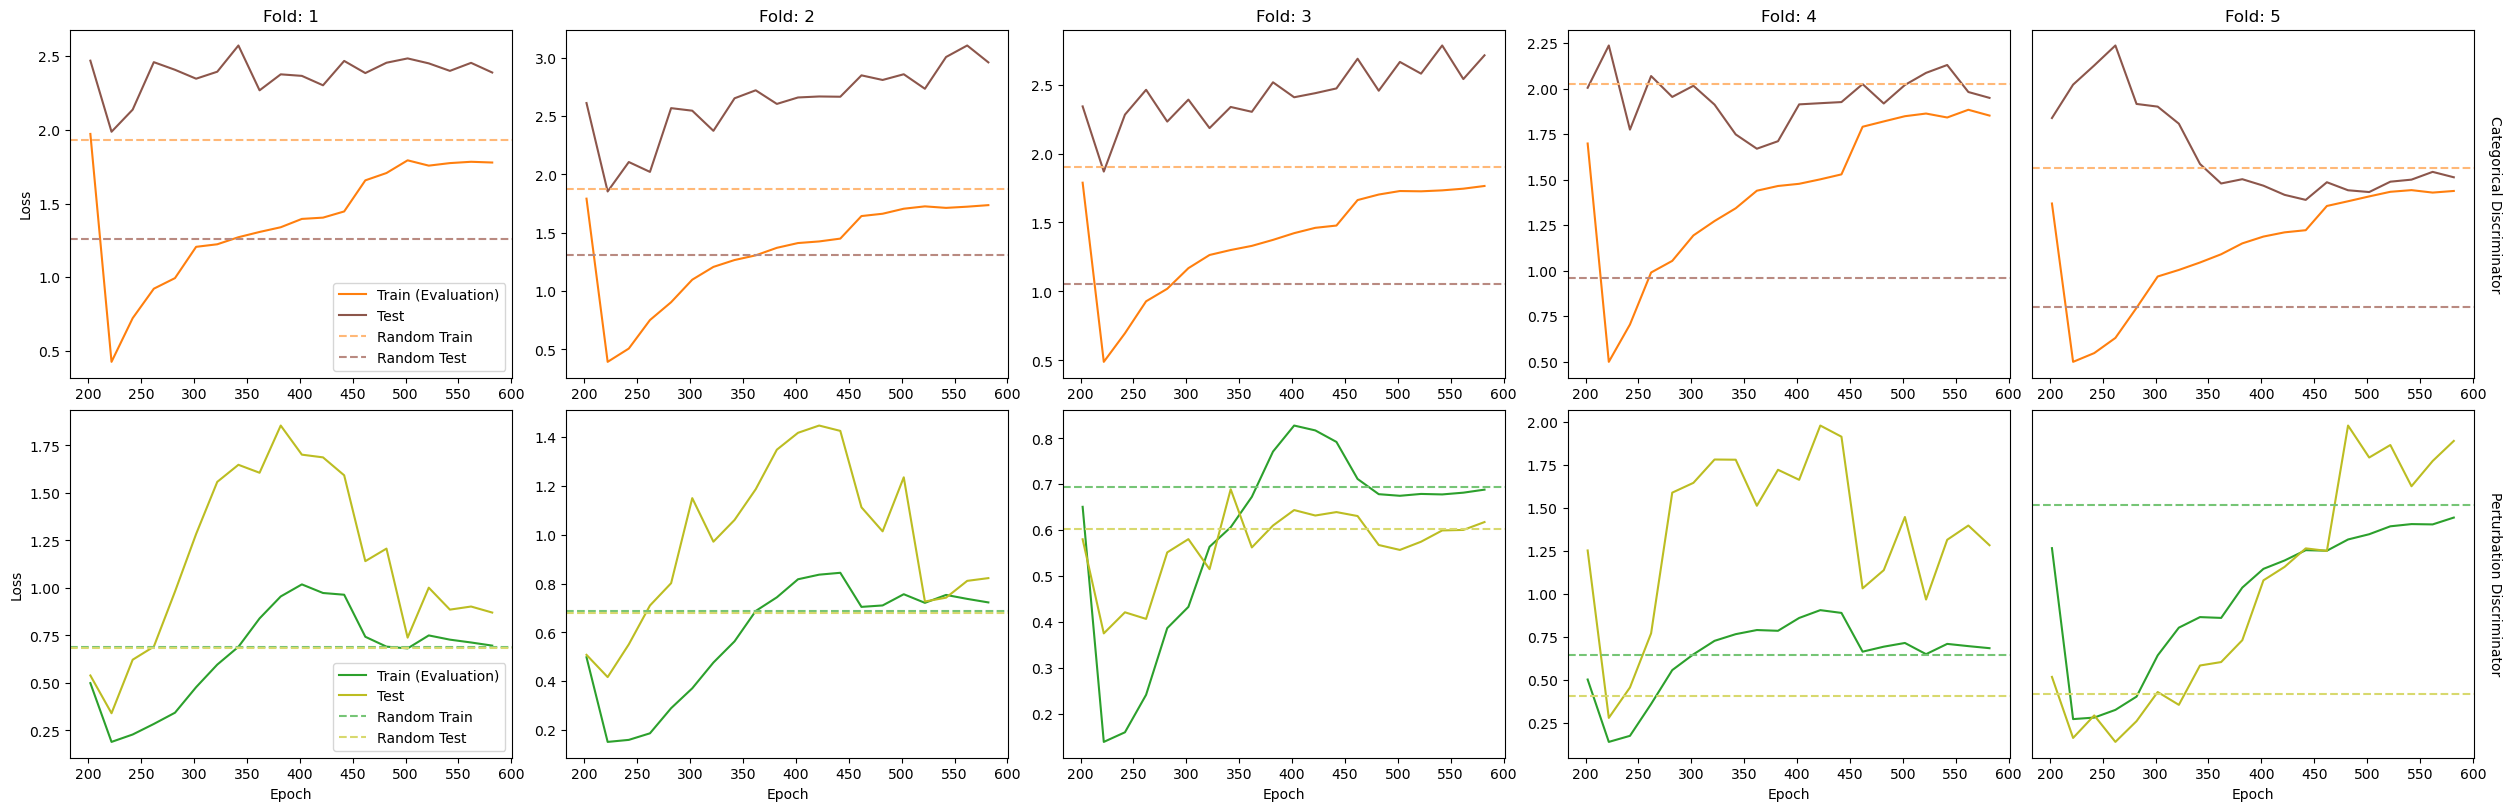

In [19]:
def plot_eval_adversarial_loss_row(
    ax_row,
    fold
):
    split = get_split(fold, author)
    train_cells =  split['train_barcodes']
    test_cells = split['test_barcodes']
    trainer = viz_dict[fold]['trainer']
    eval_df = viz_dict[fold]['eval_df'].copy()
    
    eval_df = eval_df[eval_df.epoch > trainer.n_adversarial_start]

    
    
    i = 0
    # Plot 1: categorical discriminator
    sns.lineplot(
        data=eval_df,
        x='epoch',
        y='categorical_discriminator_loss',
        hue='loss_type',
        palette=["#ff7f0e", "#8c564b"],errorbar = None,
        ax=ax_row[i],
    )

    disc = trainer.cat_discriminator['discriminators'][cat_col]
    cp_train = tf_adata[train_cells, :].obs[cat_col].value_counts(normalize=True).values
    cp_test = tf_adata[test_cells, :].obs[cat_col].value_counts(
        normalize=True, dropna=False
    ).reindex(tf_adata.obs[cat_col].cat.categories, fill_value=0).values

    if author == 'McCauley':
        rand_loss_train = corrected_random_loss(disc, cp_train, train_mode=False)
        rand_loss_test = corrected_random_loss(disc, cp_test, train_mode=False)
    else:
        rand_loss_train = disc.random_loss(cp_train, train_mode=False)
        rand_loss_test = disc.random_loss(cp_test, train_mode=False)

    ax_row[i].axhline(y=rand_loss_train, color="#ffb877", linestyle='--', label='Random Train')
    ax_row[i].axhline(y=rand_loss_test, color="#b98a81", linestyle='--', label='Random Test')

    ax_row[i].set_ylabel('Loss')

    i = 1
    # Plot 2: perturbation discriminator
    sns.lineplot(
        data=eval_df,
        x='epoch',
        y='perturbation_discriminator_loss',
        hue='loss_type',
        palette=["#2ca02c", "#bcbd22"],errorbar = None,
        ax=ax_row[i],
    )

    disc = trainer.pert_discriminator['discriminator']
    cp_train = tf_adata[train_cells, :].obs[pert_col].value_counts(normalize=True).values
    cp_test = tf_adata[test_cells, :].obs[pert_col].value_counts(
        normalize=True, dropna=False
    ).reindex(tf_adata.obs[pert_col].cat.categories, fill_value=0).values

    if author == 'McCauley':
        rand_loss_train = corrected_random_loss(disc, cp_train, train_mode=False)
        rand_loss_test = corrected_random_loss(disc, cp_test, train_mode=False)
    else:
        rand_loss_train = disc.random_loss(cp_train, train_mode=False)
        rand_loss_test = disc.random_loss(cp_test, train_mode=False)

    ax_row[i].axhline(y=rand_loss_train, color="#76c576", linestyle='--', label='Random Train')
    ax_row[i].axhline(y=rand_loss_test, color="#d8d96e", linestyle='--', label='Random Test')

    ax_row[i].set_ylabel('Loss')
    
    
old_titles = ['Categorical Discriminator', 'Perturbation Discriminator']

fig, ax = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(5 * 5, 8),
    constrained_layout=True,
)

for fold in range(5):

    plot_eval_adversarial_loss_row(
        ax_row=ax[:, fold],
        fold = fold
    )

    for r in range(2):
        a = ax[r, fold]

        # remove all titles
        a.set_title('')

        # only bottom row gets x-label
        if r != 1:
            a.set_xlabel('')
        else:
            a.set_xlabel('Epoch')

        # only first column gets y-label
        if fold != 0:
            a.set_ylabel('')

        # only first column keeps legend
        if fold != 0 and a.get_legend() is not None:
            a.get_legend().remove()
        else:
            a.legend(title = '')

    # first row: fold title
    ax[0, fold].set_title('Fold: {}'.format(fold + 1))
    
    
for r in range(2):
    a = ax[r, -1]
    a.set_ylabel(old_titles[r], rotation=270, labelpad=20)
    a.yaxis.set_label_position("right")
    a.yaxis.tick_right()
    a.tick_params(right=False, labelright=False)

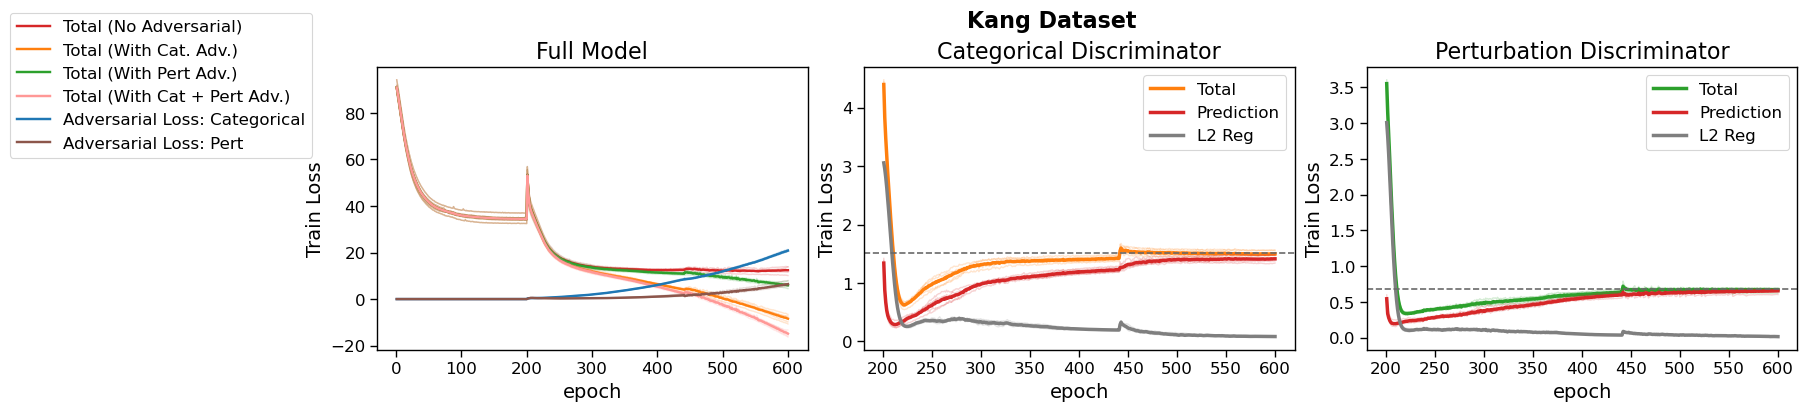

In [14]:
with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):

    colors = [
        "#d62728",  # Red
        "#ff7f0e",  # Orange
        "#2ca02c",  # Green
        "#ff9896",   # Light red
        "#1f77b4",  # Blue
        "#8c564b",  # Brown
        "#17a589",  #  Teal
        "#bcbd22",  # Olive
        "#9467bd",  # Purple
        "#e377c2",  # Pink
        "#7f7f7f",  # Gray
        "#6baed6",  # light blue

    ]
    palette = sns.color_palette(colors)


    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), constrained_layout=True)

    all_train_stats_dfs = {}
    all_train_cells = {}
    for fold in range(5):
        split = get_split(fold, author)
        train_cells = split['train_barcodes']
        trainer = viz_dict[fold]['trainer']
        assert sorted(train_cells) == sorted(trainer.X_train.index), 'Train cell mismatch'

        train_stats_df = viz_dict[fold]['train_stats'].copy()
        all_train_stats_dfs[fold] = train_stats_df
        all_train_cells[fold] = train_cells


    # =======================
    # Plot 1: full model, adversarial loss
    # =======================
    i = 0

    loss_cols_main = [
        'sign_reg_loss',
        'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
        'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss',
        'global_bias_kl_divergence'
    ]

    loss_cols = ['train_loss_total'] + loss_cols_main + ['cat_adverserial_loss', 'pert_adverserial_loss', 'train_loss_prediction']
    loss_cols_sub = [
        'total_train_loss_no_adverserial',
        'train_loss: total - cat_adverserial',
        'train_loss: total - pert_adverserial',
        'train_loss_total',
        'cat_adverserial_loss',
        'pert_adverserial_loss'
    ]
    loss_cols_name = [
        'Total (No Adversarial)',
        'Total (With Cat. Adv.)',
        'Total (With Pert Adv.)',
        'Total (With Cat + Pert Adv.)',
        'Adversarial Loss: Categorical',
        'Adversarial Loss: Pert'
    ]
    loss_name_map = dict(zip(loss_cols_sub, loss_cols_name))
    color_map = dict(zip(loss_cols_name, palette[:len(loss_cols_name)]))

    all_viz_dfs = {}
    for fold in range(5):
        trainer = viz_dict[fold]['trainer']
        train_stats_df = all_train_stats_dfs[fold]

        viz_df = train_stats_df[['epoch'] + loss_cols].copy()
        viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main + ['train_loss_prediction']].sum(axis=1)

        viz_df.drop(columns=loss_cols_main, inplace=True)
        viz_df.drop(columns=['train_loss_prediction'], inplace=True)

        if trainer.gradient_ascent:
            for adv_col in ['cat_adverserial_loss', 'pert_adverserial_loss']:
                viz_df[adv_col] = viz_df[adv_col].abs()
            viz_df['train_loss_total'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss - viz_df.pert_adverserial_loss

        viz_df['train_loss: total - cat_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss
        viz_df['train_loss: total - pert_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.pert_adverserial_loss

        viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
        viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols_sub)
        viz_df.loss_type = viz_df.loss_type.map(loss_name_map)

        all_viz_dfs[fold] = viz_df

    for lti, loss_type in enumerate(loss_cols_name):
        for fold in range(5):
            viz_df = all_viz_dfs[fold]
            sub = viz_df[viz_df.loss_type == loss_type]
            first_line = sns.lineplot(
                data=sub,
                x='epoch', y='loss',
                errorbar=None,
                color=color_map[loss_type],
                ax=ax[i],
                alpha=0.2,
                linewidth=1
            )
            first_line.get_lines()[-1].set_color(color_map[loss_type])

        avg_df = (
            pd.concat(all_viz_dfs.values())
            .query("loss_type == @loss_type")
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=avg_df,
            x='epoch', y='loss',
            errorbar=None,
            color=color_map[loss_type],
            ax=ax[i],
            alpha=1,
            linewidth=1.75,
            label=loss_type
        )

    # ax[i].legend(loc='upper left', bbox_to_anchor=(-0.05, 1), borderaxespad=0.)
    ax[i].set_ylabel('Train Loss')
    ax[i].set_title('Full Model')


    # =======================
    # Plot 2: categorical discriminator loss
    # =======================
    i = 1

    loss_cols_disc = ['cat_discriminator_loss_total',
                      'cat_discriminator_loss_prediction', 'cat_discriminator_param_reg_loss']
    loss_cols_name = ['Total', 'Prediction', 'L2 Reg']

    all_viz_dfs = {}
    loss_cols_disc_final = None
    for fold in range(5):
        trainer = viz_dict[fold]['trainer']
        train_stats_df = all_train_stats_dfs[fold]

        viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
        viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

        curr_loss_cols_disc = loss_cols_disc.copy()
        if (viz_df[curr_loss_cols_disc[-1]] == 0).all():
            curr_loss_cols_disc = [curr_loss_cols_disc[0]]
            viz_df = train_stats_df[['epoch'] + curr_loss_cols_disc].copy()
            viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

        if loss_cols_disc_final is None:
            loss_cols_disc_final = curr_loss_cols_disc

        viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
        viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=curr_loss_cols_disc)
        viz_df.loss_type = viz_df.loss_type.map(dict(zip(curr_loss_cols_disc, loss_cols_name[:len(curr_loss_cols_disc)])))

        all_viz_dfs[fold] = viz_df

    curr_loss_cols_name = loss_cols_name[:len(loss_cols_disc_final)]
    curr_palette = (
        [palette[1]] if loss_cols_disc_final == [loss_cols_disc_final[0]]
        else [palette[1], palette[0], palette[-2]]
    )
    color_map = dict(zip(curr_loss_cols_name, curr_palette))

    for loss_type in curr_loss_cols_name:
        for fold in range(5):
            viz_df = all_viz_dfs[fold]
            sub = viz_df[viz_df.loss_type == loss_type]
            first_line = sns.lineplot(
                data=sub,
                x='epoch', y='loss',
                errorbar=None,
                color=color_map[loss_type],
                ax=ax[i],
                alpha=0.2,
                linewidth=1
            )
            first_line.get_lines()[-1].set_color(color_map[loss_type])

        avg_df = (
            pd.concat(all_viz_dfs.values())
            .query("loss_type == @loss_type")
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=avg_df,
            x='epoch', y='loss',
            errorbar=None,
            color=color_map[loss_type],
            ax=ax[i],
            alpha=1,
            linewidth=2.5,
            label=loss_type
        )

    rand_losses = []
    for fold in range(5):
        trainer = viz_dict[fold]['trainer']
        train_cells = all_train_cells[fold]
        cp = tf_adata[train_cells, :].obs[cat_col].value_counts(normalize=True).values
        if author == 'McCauley':
            rand_loss = corrected_random_loss(
                discriminator=trainer.cat_discriminator['discriminators'][cat_col],
                class_probs=cp, train_mode=True
            )
        else:
            rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(
                class_probs=cp, train_mode=True
            )
        rand_losses.append(rand_loss)

    ax[i].axhline(y=np.mean(rand_losses), color='dimgray', linestyle='--')

    # if len(curr_loss_cols_name) == 1 and ax[i].get_legend() is not None:
    #     ax[i].legend_.remove()
    # else:
    #     ax[i].legend(loc='best')

    ax[i].set_ylabel('Train Loss')
    ax[i].set_title('Categorical Discriminator')


    # =======================
    # Plot 3: perturbation discriminator loss
    # =======================
    i = 2

    loss_cols_disc = ['pert_discriminator_loss_total',
                      'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']
    loss_cols_name = ['Total', 'Prediction', 'L2 Reg']

    all_viz_dfs = {}
    loss_cols_disc_final = None
    for fold in range(5):
        trainer = viz_dict[fold]['trainer']
        train_stats_df = all_train_stats_dfs[fold]

        viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
        viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

        curr_loss_cols_disc = loss_cols_disc.copy()
        if (viz_df[curr_loss_cols_disc[-1]] == 0).all():
            curr_loss_cols_disc = [curr_loss_cols_disc[0]]
            viz_df = train_stats_df[['epoch'] + curr_loss_cols_disc].copy()
            viz_df = viz_df[viz_df.epoch > trainer.n_adversarial_start]

        if loss_cols_disc_final is None:
            loss_cols_disc_final = curr_loss_cols_disc

        viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
        viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=curr_loss_cols_disc)
        viz_df.loss_type = viz_df.loss_type.map(dict(zip(curr_loss_cols_disc, loss_cols_name[:len(curr_loss_cols_disc)])))

        all_viz_dfs[fold] = viz_df

    curr_loss_cols_name = loss_cols_name[:len(loss_cols_disc_final)]
    curr_palette = (
        [palette[2]] if loss_cols_disc_final == [loss_cols_disc_final[0]]
        else [palette[2], palette[0], palette[-2]]
    )
    color_map = dict(zip(curr_loss_cols_name, curr_palette))

    for loss_type in curr_loss_cols_name:
        for fold in range(5):
            viz_df = all_viz_dfs[fold]
            sub = viz_df[viz_df.loss_type == loss_type]
            first_line = sns.lineplot(
                data=sub,
                x='epoch', y='loss',
                errorbar=None,
                color=color_map[loss_type],
                ax=ax[i],
                alpha=0.2,
                linewidth=1
            )
            first_line.get_lines()[-1].set_color(color_map[loss_type])

        avg_df = (
            pd.concat(all_viz_dfs.values())
            .query("loss_type == @loss_type")
            .groupby('epoch')['loss']
            .mean()
            .reset_index()
        )
        sns.lineplot(
            data=avg_df,
            x='epoch', y='loss',
            errorbar=None,
            color=color_map[loss_type],
            ax=ax[i],
            alpha=1,
            linewidth=2.5,
            label=loss_type
        )

    rand_losses = []
    for fold in range(5):
        trainer = viz_dict[fold]['trainer']
        train_cells = all_train_cells[fold]
        cp = tf_adata[train_cells, :].obs[pert_col].value_counts(normalize=True).values

        if author == 'McCauley':
            rand_loss = corrected_random_loss(
                discriminator=trainer.pert_discriminator['discriminator'],
                class_probs=cp, train_mode=True
            )
        else:
            rand_loss = trainer.pert_discriminator['discriminator'].random_loss(
                class_probs=cp, train_mode=True
            )
        rand_losses.append(rand_loss)

    ax[i].axhline(y=np.mean(rand_losses), color='dimgray', linestyle='--')

    ax[i].set_ylabel('Train Loss')
    ax[i].set_title('Perturbation Discriminator')



    for i in range(3):
        if i == 0:
            handles, labels = ax[i].get_legend_handles_labels()
            ax[i].legend_.remove()
            fig.legend(
                handles, labels,
                loc='center left',
                bbox_to_anchor=(-0.2, 0.8),
            )
        else:
            ax[i].legend(loc='upper right')
    fig.suptitle('{} Dataset'.format(author), fontsize=16, fontweight='bold')
    fig.savefig(os.path.join(data_path, 'figures', '{}_adversarial_training_dynamics.png'.format(author)), dpi=600, bbox_inches='tight')
    
    